In [ ]:
# NovaTel Customer Churn Prediction

## Overview

# The goal of this notebook is to predict the probability that a NovaTel customer will churn.

# Rather than treating this as a pure modeling problem, I approach it as a structured investigation of customer behavior.

# The analysis focuses on:

# - Missing-value patterns and whether missingness itself contains signal
# - Distribution differences between churned and retained customers
# - Non-linear relationships with churn
# - Feature interactions
# - Segment-specific churn behavior
# - Redundant and derived variables (As i will approach with tree model i dont handle this 1st)  
# - Leakage-safe validation
# - Model comparison and ensemble blending

# The final model is selected based on cross-validated ROC-AUC rather than a single validation split.

In [1]:
import pandas as pd 
train = pd.read_csv("/kaggle/input/datasets/problemthinkerbox/novatel/train.csv")
test = pd.read_csv("/kaggle/input/datasets/problemthinkerbox/novatel/test.csv")

# Initial Audit of Data

In [2]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(train.info())

Train shape: (12000, 35)
Test shape: (8000, 34)


,customer_id,age,tenure_months,number_of_services,data_usage_gb,streaming_hours_monthly,device_age_months,app_sessions_weekly,average_session_minutes,payment_delay_days,...,support_plan,payment_method,promotion_type,streaming_service,priority_support,autopay,paperless_billing,family_plan,international_plan,churn
0,NVT-LGAUGXNSBQFF,50.0,59.0,5.0,5.91,0.0,55.0,14.0,10.4,0.0,...,NovaCare Basic,Credit card (autopay),Loyalty credit,0.0,0.0,1.0,1.0,1.0,0.0,0
1,NVT-KK5E9TRTJYUG,28.0,29.0,4.0,3.03,NaN,3.0,10.0,4.9,0.0,...,NovaCare Premium,Credit card (autopay),No Promotion,0.0,1.0,NaN,1.0,0.0,1.0,0
2,NVT-WC2AWMHHLTTM,59.0,14.0,7.0,86.69,0.0,10.0,10.0,8.1,0.0,...,NovaCare Premium,Bank transfer (autopay),No Promotion,0.0,1.0,1.0,NaN,0.0,1.0,0
3,NVT-WN5PLHPLH7T4,41.0,9.0,1.0,96.32,3.5,2.0,NaN,21.9,0.0,...,No Plan,Bank transfer (autopay),Free month,1.0,0.0,1.0,0.0,0.0,0.0,1
4,NVT-U2ZXSGY3KM9C,55.0,38.0,NaN,3.38,0.0,9.0,11.0,NaN,0.0,...,NaN,Bank transfer (autopay),NaN,0.0,0.0,NaN,1.0,0.0,0.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              12000 non-null  object 
 1   age                      11628 non-null  float64
 2   tenure_months            11520 non-null  float64
 3   number_of_services       11584 non-null  float64
 4   data_usage_gb            11493 non-null  float64
 5   streaming_hours_monthly  11192 non-null  float64
 6   device_age_months        11664 non-null  float64
 7   app_sessions_weekly      11498 non-null  float64
 8   average_session_minutes  11425 non-null  float64
 9   payment_delay_days       11346 non-null  float64
 10  late_payment_count       11420 non-null  float64
 11  discount_percentage      11374 non-null  float64
 12  monthly_charge           11548 non-null  float64
 13  network_complaints       11373 non-null  float64
 14  support_calls_90d     

None

In [4]:
print("Duplicate rows:", train.duplicated().sum())
print("Duplicate customer IDs:", train["customer_id"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [5]:
target_summary = pd.DataFrame({
    "Count": train["churn"].value_counts(),
    "Percentage": train["churn"].value_counts(normalize=True) * 100
})

target_summary

,Count,Percentage
churn,,
0,9037,75.308333
1,2963,24.691667


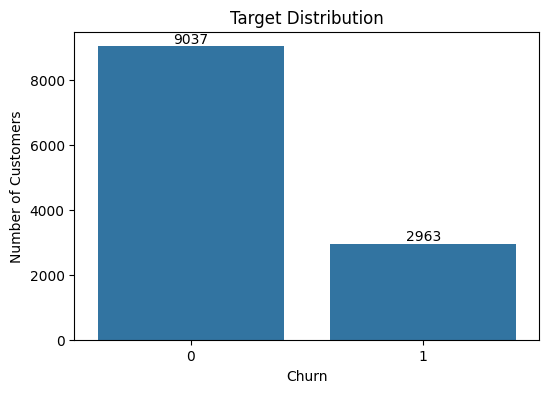

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=train,
    x="churn"
)

plt.title("Target Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

**This is a class imbalance problem but as the metric for the problem is not accuracy so i didnt give headache for the Imbalance handling process**

## Ydata Profiling to easily visualize the data 

In [10]:
!pip install ydata-profiling 

In [14]:
from ydata_profiling import ProfileReport
prof = ProfileReport(train)
prof.to_file(output_file='/kaggle/working/data.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 35/35 [00:01<00:00, 20.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Missing-Value Investigation and EDA

**For churn analysis sometimes it is important to analyze the importance of missing data**

A missing value can arise because:

- the information was not collected,
- the customer did not provide it,
- or the absence itself may reflect customer behavior.
I investigate both the amount of missingness and whether missingness is associated with churn.

In [15]:
missing_summary = pd.DataFrame({
    "Missing Count": train.isna().sum(),
    "Missing %": train.isna().mean() * 100,
    "Data Type": train.dtypes
})

missing_summary = (
    missing_summary
    .sort_values("Missing %", ascending=False)
)

display(missing_summary)

,Missing Count,Missing %,Data Type
streaming_hours_monthly,808,6.733333,float64
satisfaction_score,674,5.616667,float64
payment_delay_days,654,5.450000,float64
support_calls_90d,653,5.441667,float64
network_complaints,627,5.225000,float64
discount_percentage,626,5.216667,float64
late_payment_count,580,4.833333,float64
average_session_minutes,575,4.791667,float64
referral_count,574,4.783333,float64
payment_method,558,4.650000,object


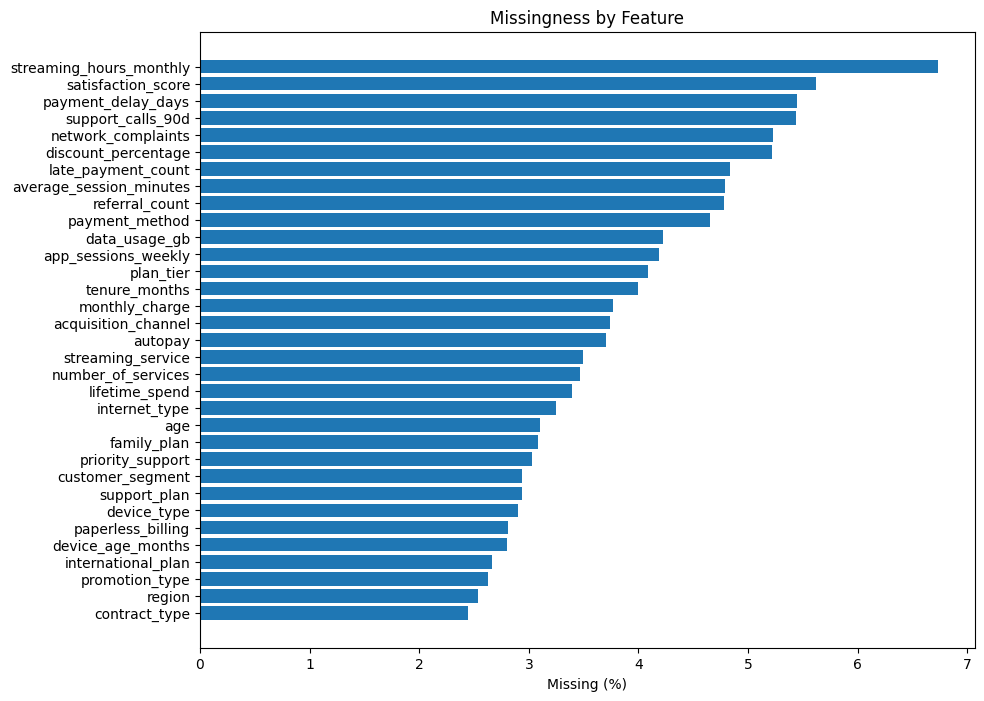

In [16]:
missing_plot = (
    missing_summary
    .query("`Missing Count` > 0")
    .sort_values("Missing %")
)

plt.figure(figsize=(10, 8))

plt.barh(
    missing_plot.index,
    missing_plot["Missing %"]
)

plt.xlabel("Missing (%)")
plt.title("Missingness by Feature")

plt.show()

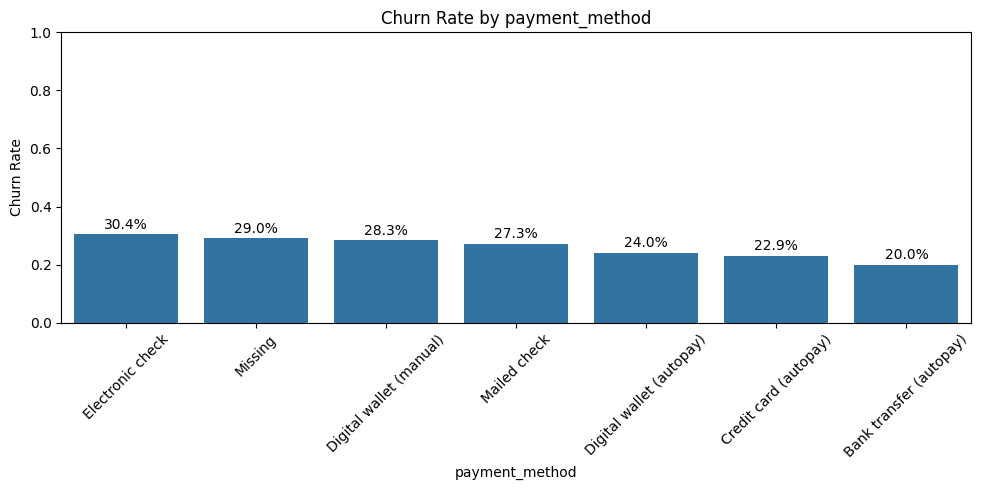

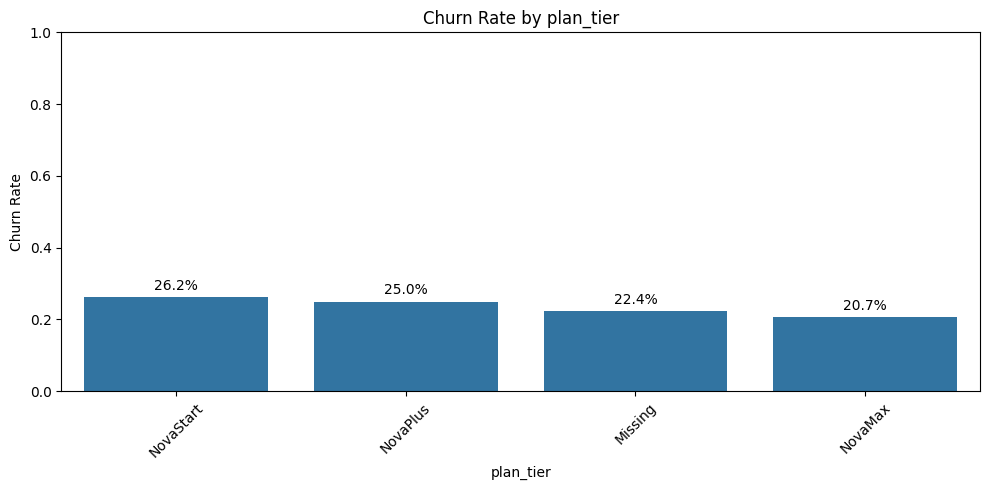

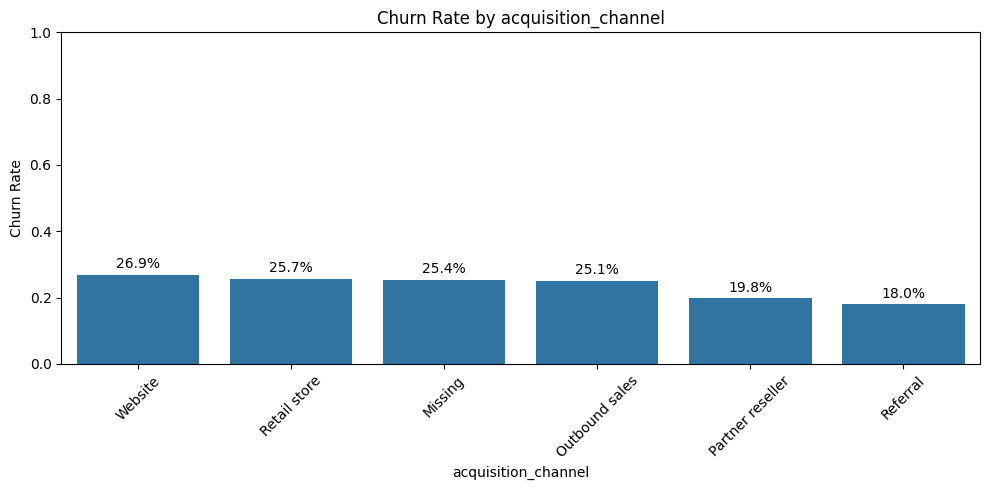

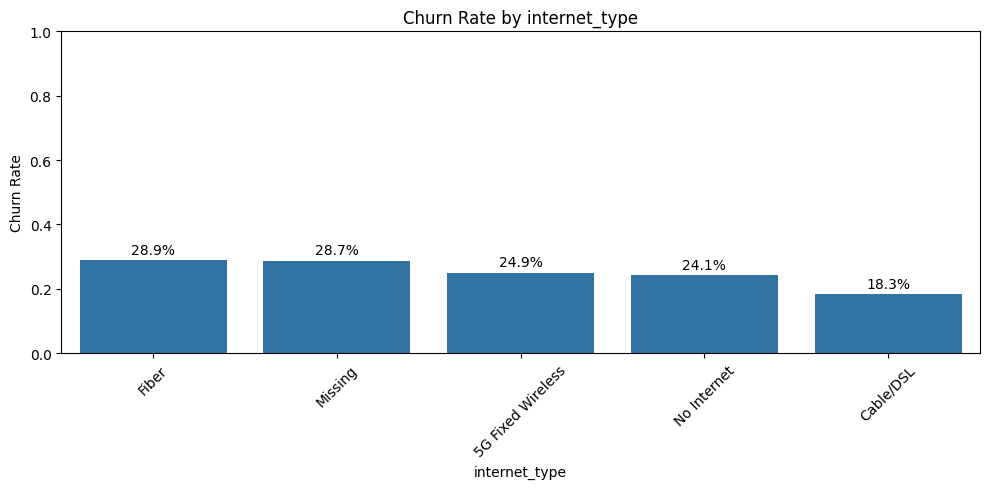

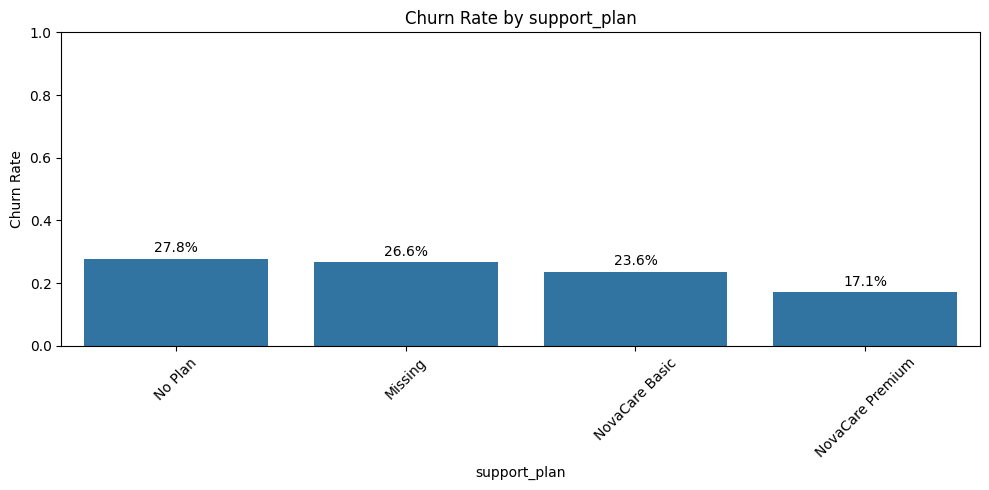

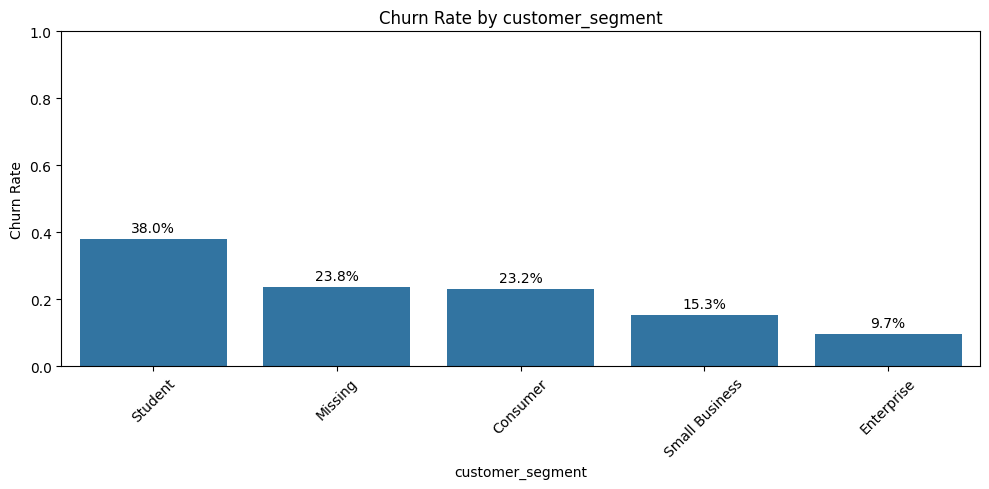

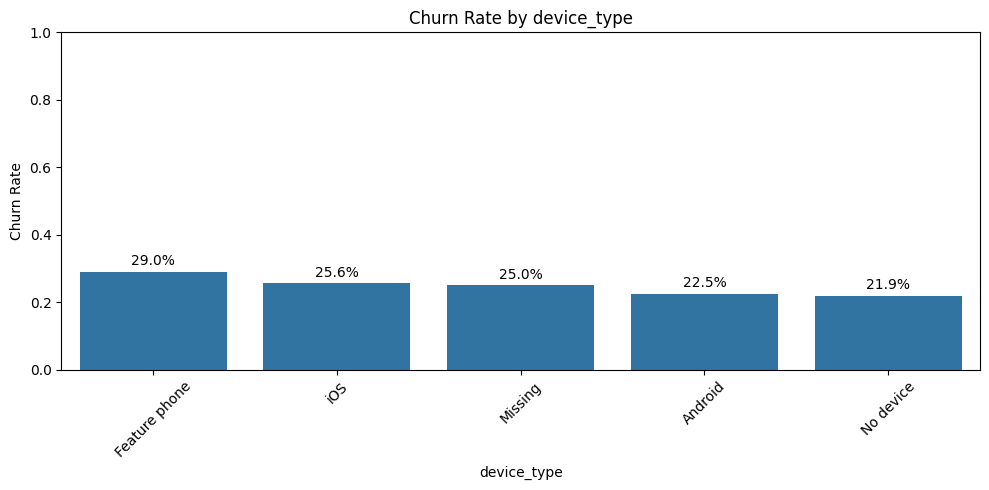

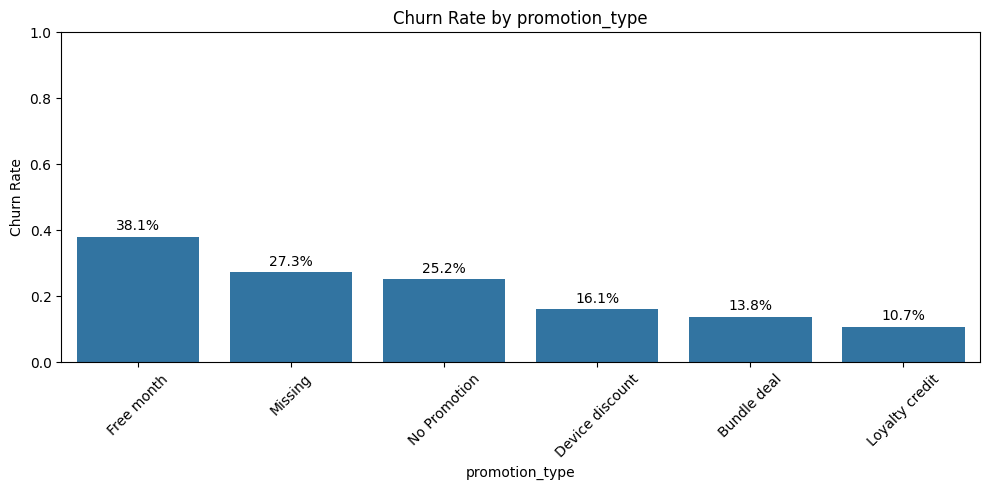

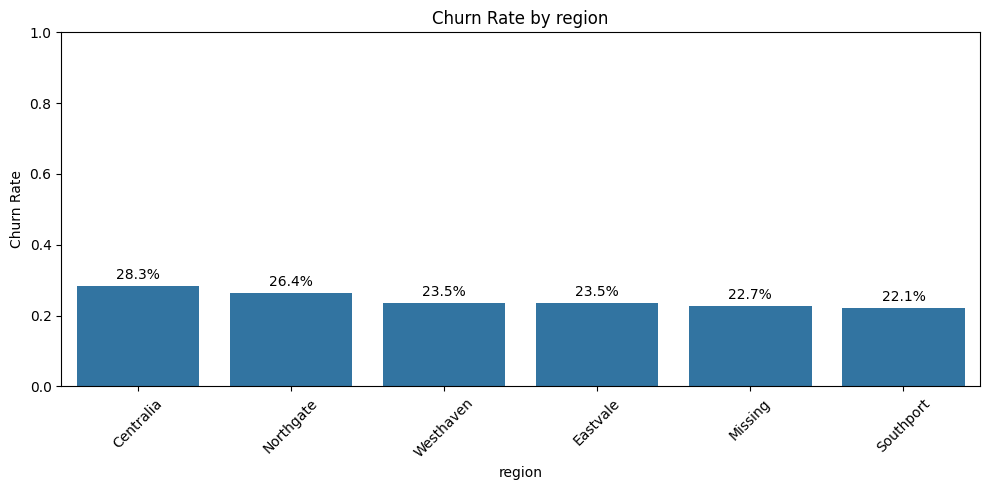

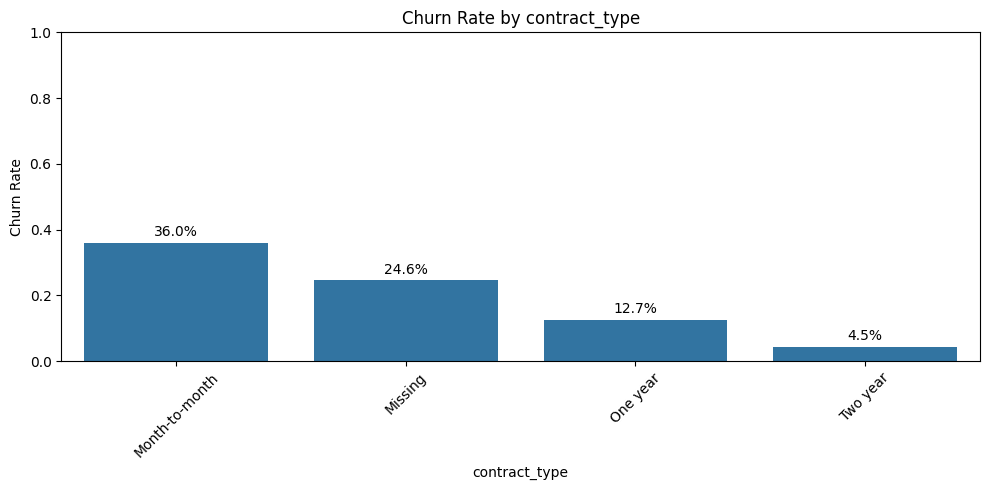

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# 1. Create a separate copy for EDA
# ============================================================

eda_train = train.copy()


# ============================================================
# 2. Define categorical columns
# ============================================================

categorical_cols = [
    "payment_method",
    "plan_tier",
    "acquisition_channel",
    "internet_type",
    "support_plan",
    "customer_segment",
    "device_type",
    "promotion_type",
    "region",
    "contract_type"
]


# ============================================================
# 3. Analyze categorical features
#    Missing values are treated as a separate category
# ============================================================

for col in categorical_cols:

    # Keep missing values visible as a category
    eda_train[col] = eda_train[col].fillna("Missing")

    # Calculate churn rate for each category
    churn_rate = (
        eda_train
        .groupby(col)["churn"]
        .mean()
        .sort_values(ascending=False)
    )

    # Plot
    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values
    )

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")

    plt.xticks(rotation=45)
    plt.ylim(0, 1)

    # Add percentage labels
    for i, value in enumerate(churn_rate.values):
        plt.text(
            i,
            value + 0.02,
            f"{value:.1%}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()


In [21]:


# ============================================================
# 4. Define numerical columns
# ============================================================

numeric_cols = (
    eda_train
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

# Remove target variable
numeric_cols.remove("churn")


# ============================================================
# 5. Analyze missingness before imputation
# ============================================================

missing_impact = []

for col in numeric_cols:

    missing_mask = eda_train[col].isna()

    # Skip columns with no missing values
    if missing_mask.sum() == 0:
        continue

    missing_churn_rate = (
        eda_train.loc[missing_mask, "churn"].mean()
    )

    present_churn_rate = (
        eda_train.loc[~missing_mask, "churn"].mean()
    )

    missing_impact.append({
        "Feature": col,
        "Missing Count": missing_mask.sum(),
        "Missing %": missing_mask.mean() * 100,
        "Churn Rate (Missing)": missing_churn_rate,
        "Churn Rate (Present)": present_churn_rate,
        "Difference": missing_churn_rate - present_churn_rate
    })


missing_impact_df = pd.DataFrame(missing_impact)

missing_impact_df = (
    missing_impact_df
    .sort_values(
        "Difference",
        key=abs,
        ascending=False
    )
)

missing_impact_df




,Feature,Missing Count,Missing %,Churn Rate (Missing),Churn Rate (Present),Difference
12,network_complaints,627,5.225000,0.293461,0.244351,0.049110
17,streaming_service,419,3.491667,0.202864,0.248510,-0.045647
14,satisfaction_score,674,5.616667,0.289318,0.244393,0.044924
15,referral_count,574,4.783333,0.280488,0.245230,0.035258
11,monthly_charge,452,3.766667,0.278761,0.245670,0.033091
13,support_calls_90d,653,5.441667,0.215926,0.248700,-0.032774
5,device_age_months,336,2.800000,0.217262,0.247771,-0.030509
16,lifetime_spend,407,3.391667,0.218673,0.247908,-0.029235
19,autopay,445,3.708333,0.274157,0.245868,0.028290
9,late_payment_count,580,4.833333,0.220690,0.248249,-0.027559


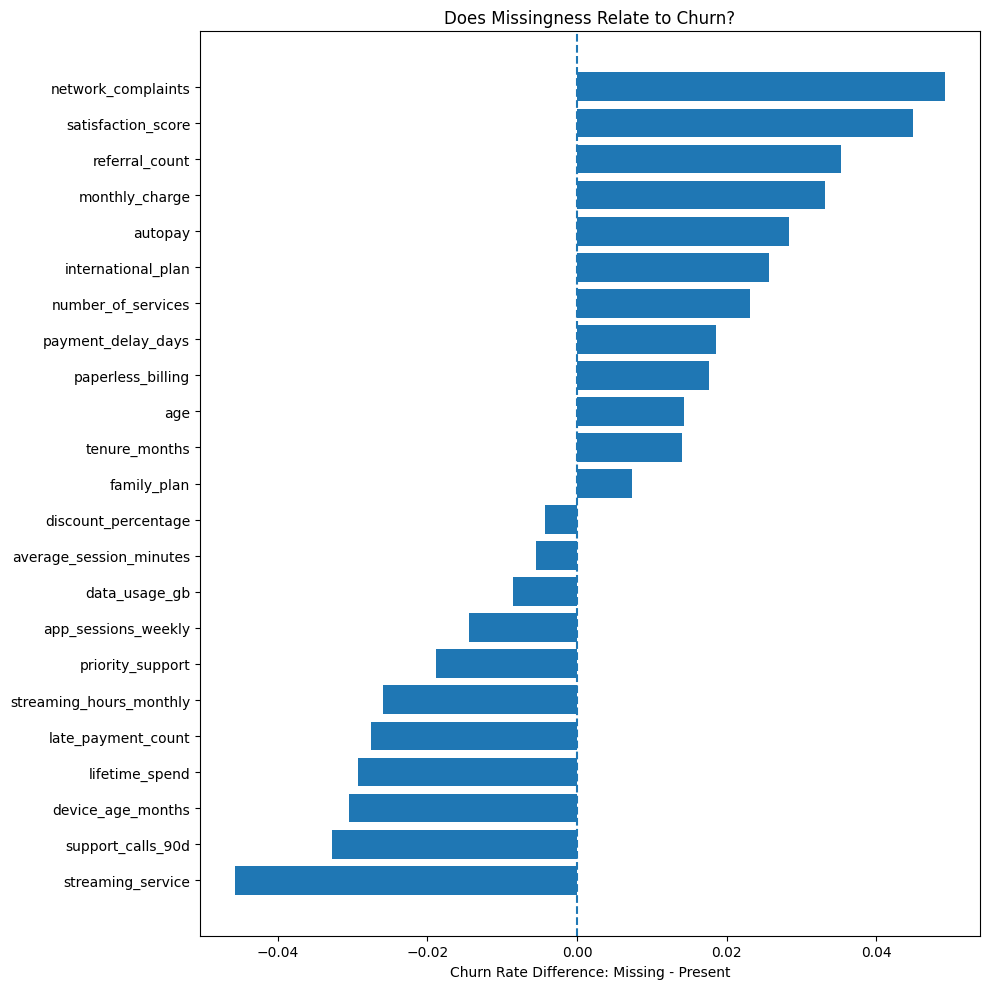

In [22]:
plot_df = missing_impact_df.sort_values(
    "Difference"
)

plt.figure(figsize=(10, 10))

plt.barh(
    plot_df["Feature"],
    plot_df["Difference"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Churn Rate Difference: Missing - Present"
)

plt.title(
    "Does Missingness Relate to Churn?"
)

plt.tight_layout()
plt.show()

## Interpretation


The analysis suggests that missingness is not uniformly distributed with respect to churn.
some variables show noticeably different churn rates when their values are missing compared with when they are observed.
This motivates treating selected missingness indicators as candidate predictive features rather than automatically replacing all missing values and discarding the information about whether the value was missing.

In [23]:
for col in categorical_cols:

    temp = (
        eda_train
        .groupby(col)["churn"]
        .agg(
            Customers="count",
            Churn_Rate="mean"
        )
        .sort_values("Churn_Rate", ascending=False)
    )

    display(temp)

,Customers,Churn_Rate
payment_method,,
Electronic check,1803,0.303938
Missing,558,0.290323
Digital wallet (manual),862,0.283063
Mailed check,1200,0.272500
Digital wallet (autopay),1884,0.240446
Credit card (autopay),3083,0.228998
Bank transfer (autopay),2610,0.200383


,Customers,Churn_Rate
plan_tier,,
NovaStart,4856,0.262356
NovaPlus,4734,0.249683
Missing,490,0.224490
NovaMax,1920,0.206771


,Customers,Churn_Rate
acquisition_channel,,
Website,4031,0.268668
Retail store,1393,0.256999
Missing,449,0.253898
Outbound sales,4063,0.251046
Partner reseller,918,0.198257
Referral,1146,0.179756


,Customers,Churn_Rate
internet_type,,
Fiber,5054,0.288682
Missing,390,0.287179
5G Fixed Wireless,2258,0.249336
No Internet,754,0.241379
Cable/DSL,3544,0.182562


,Customers,Churn_Rate
support_plan,,
No Plan,5555,0.277768
Missing,353,0.266289
NovaCare Basic,4359,0.236293
NovaCare Premium,1733,0.170802


,Customers,Churn_Rate
customer_segment,,
Student,2658,0.379985
Missing,353,0.237960
Consumer,6828,0.232279
Small Business,1305,0.153257
Enterprise,856,0.096963


,Customers,Churn_Rate
device_type,,
Feature phone,1357,0.289609
iOS,5490,0.255920
Missing,348,0.250000
Android,4344,0.224908
No device,461,0.219089


,Customers,Churn_Rate
promotion_type,,
Free month,3395,0.381149
Missing,315,0.273016
No Promotion,3892,0.251542
Device discount,1679,0.160810
Bundle deal,1384,0.138006
Loyalty credit,1335,0.107116


,Customers,Churn_Rate
region,,
Centralia,1656,0.283213
Northgate,3200,0.264062
Westhaven,2140,0.235047
Eastvale,2795,0.234705
Missing,304,0.226974
Southport,1905,0.220997


,Customers,Churn_Rate
contract_type,,
Month-to-month,6728,0.360285
Missing,293,0.245734
One year,2986,0.126591
Two year,1993,0.044656


## Numerical EDA

## Numerical Feature Analysis

For numerical variables, I examine:

1. Distribution shape
2. Difference between churned and retained customers
3. Potential skewness
4. Potential outliers
5. Possible non-linear relationships

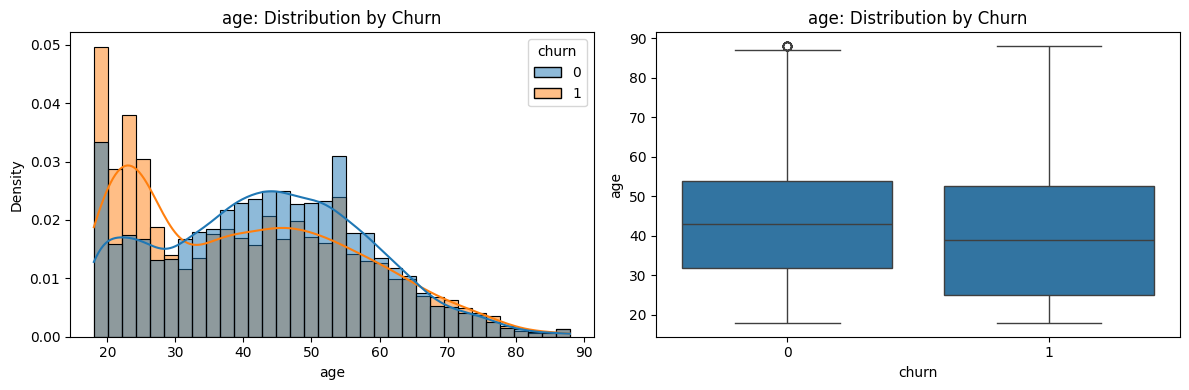

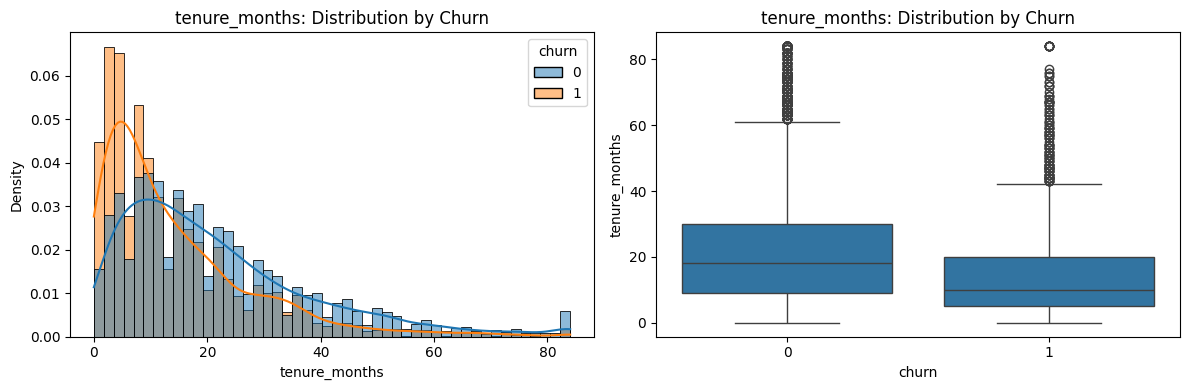

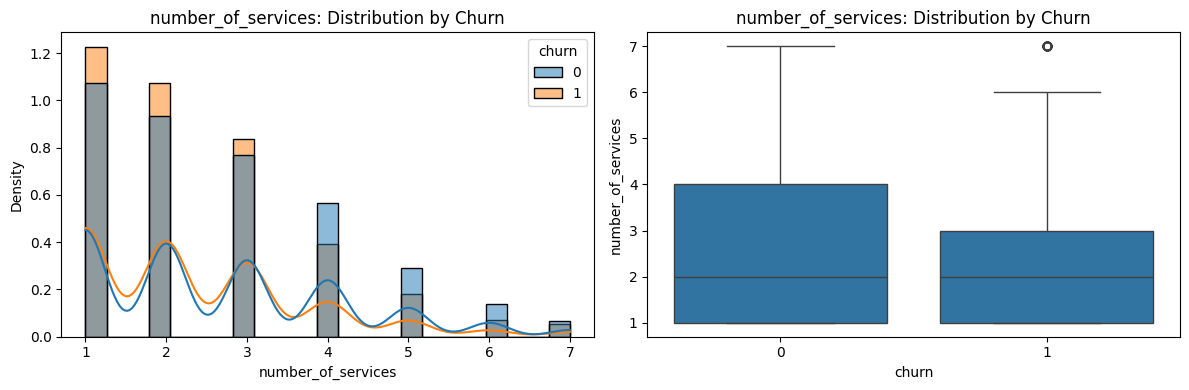

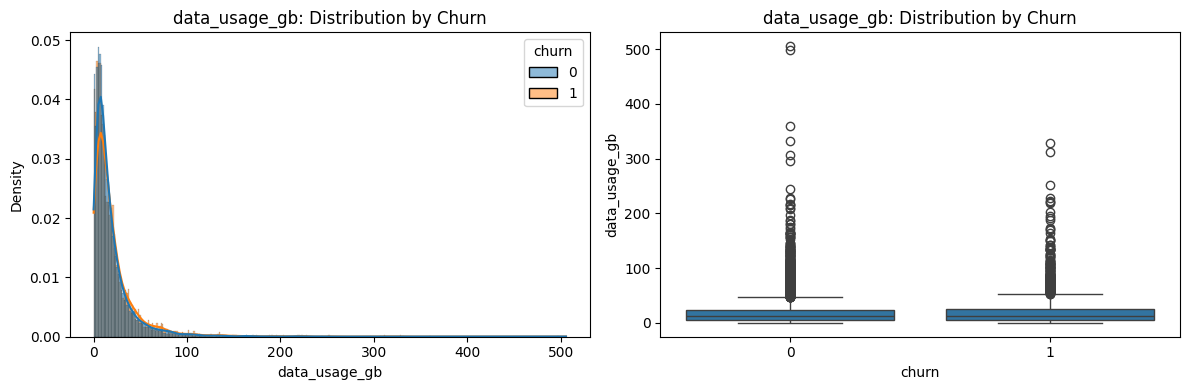

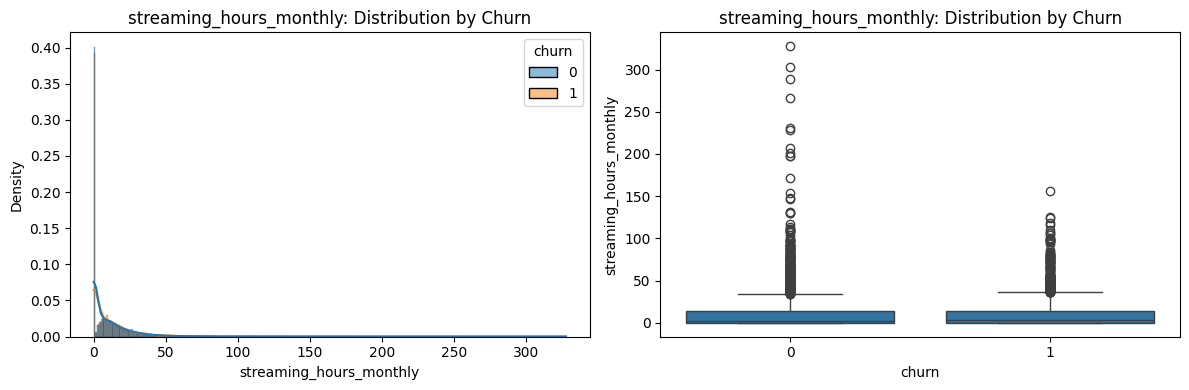

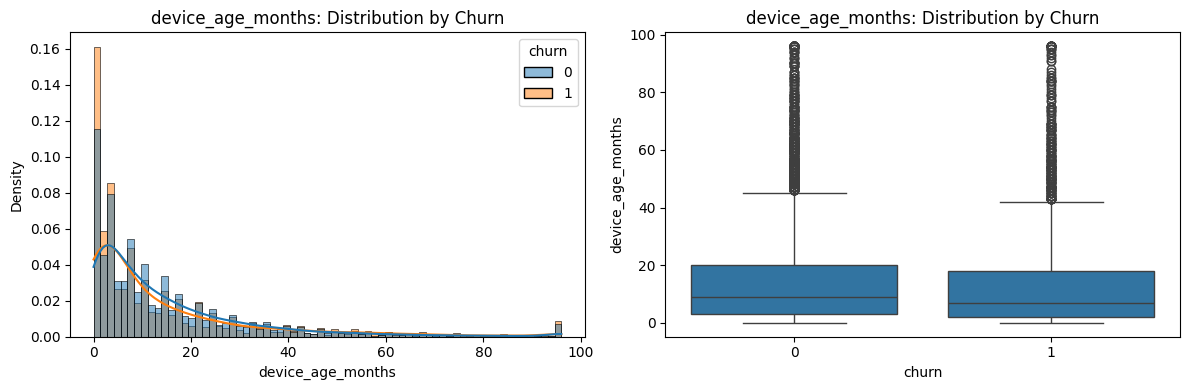

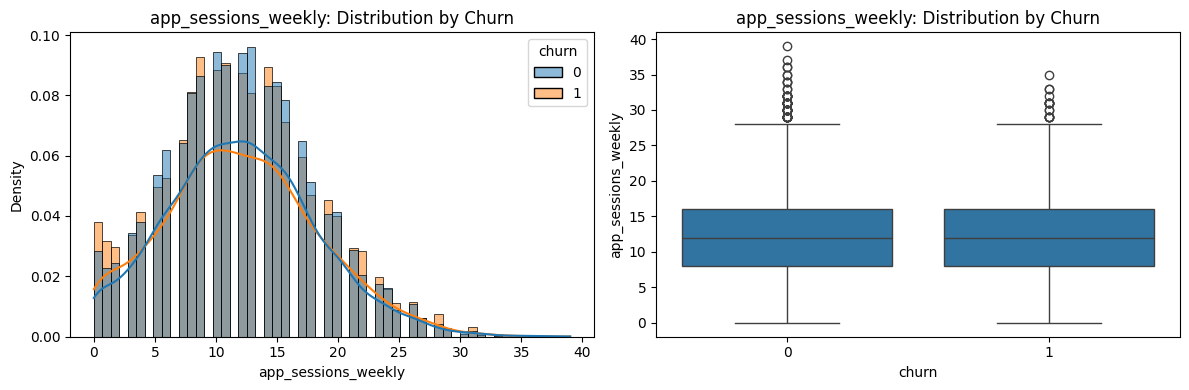

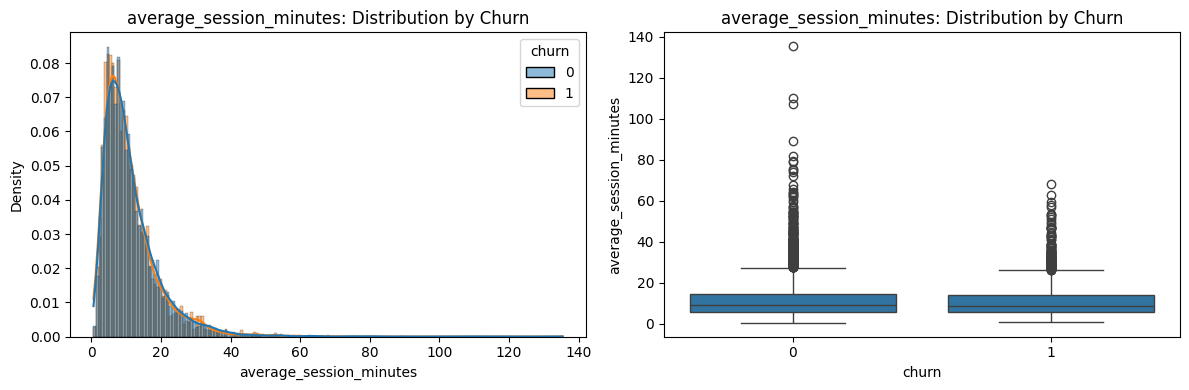

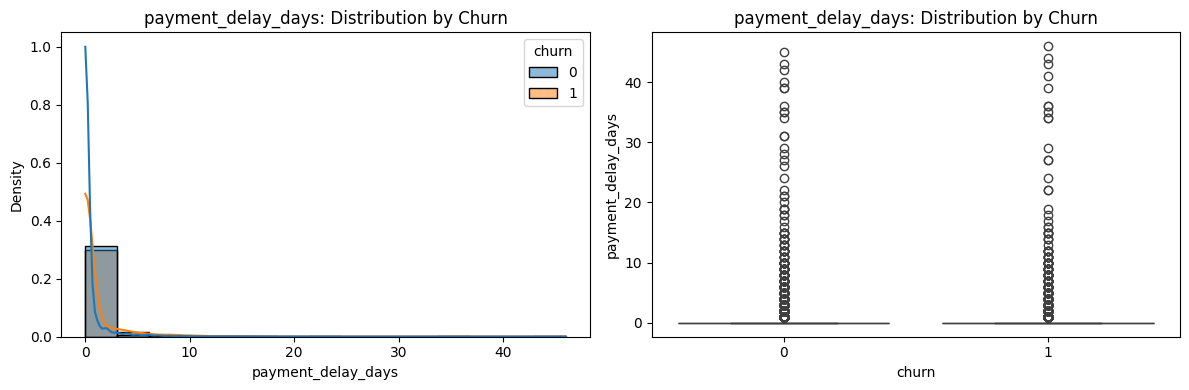

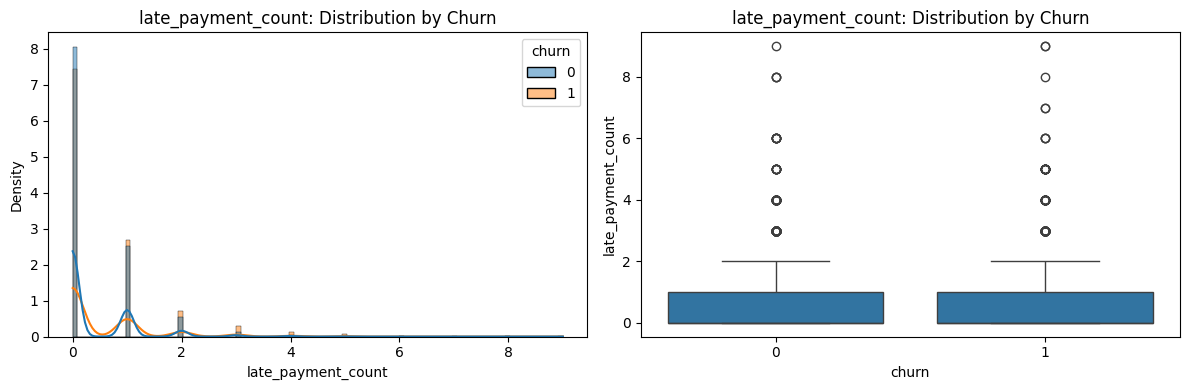

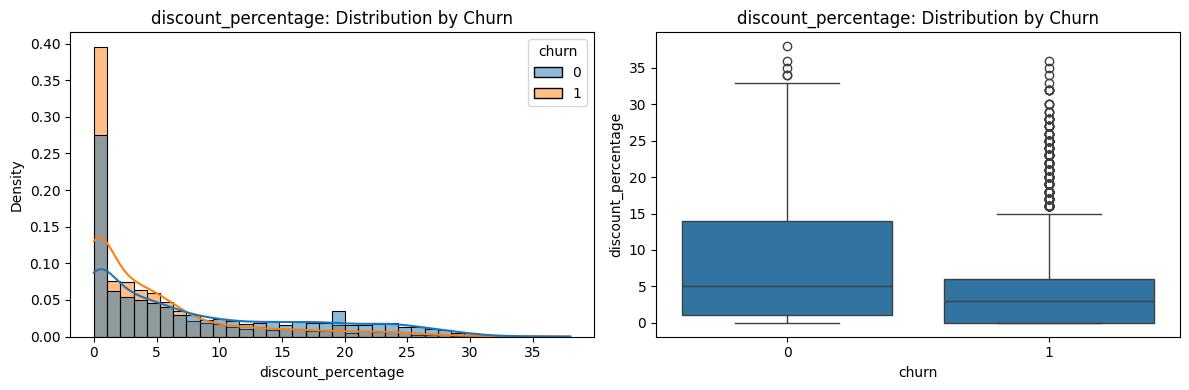

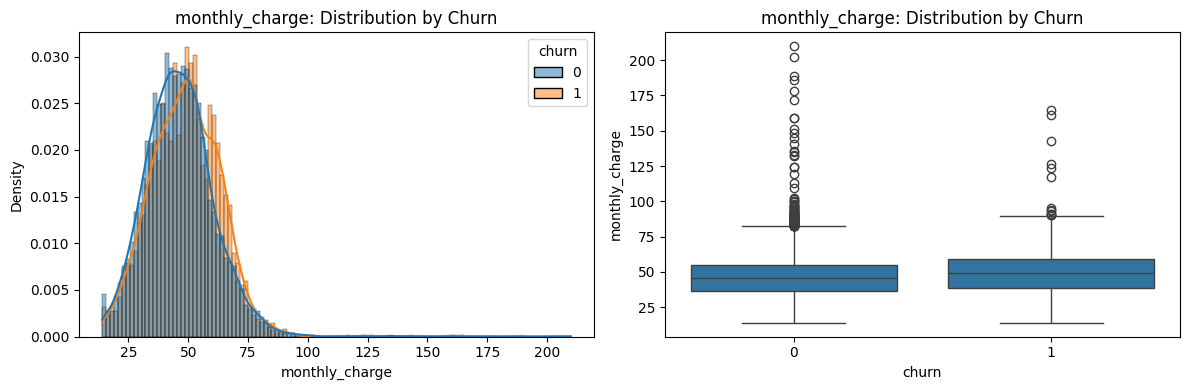

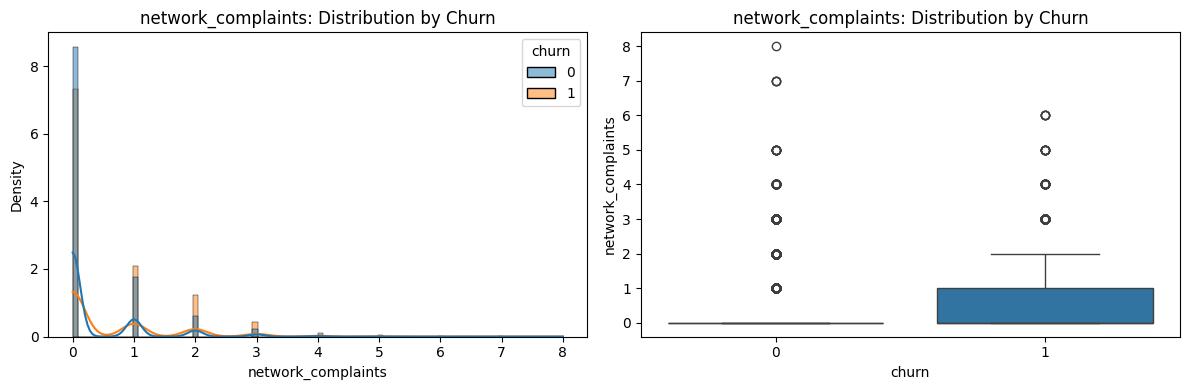

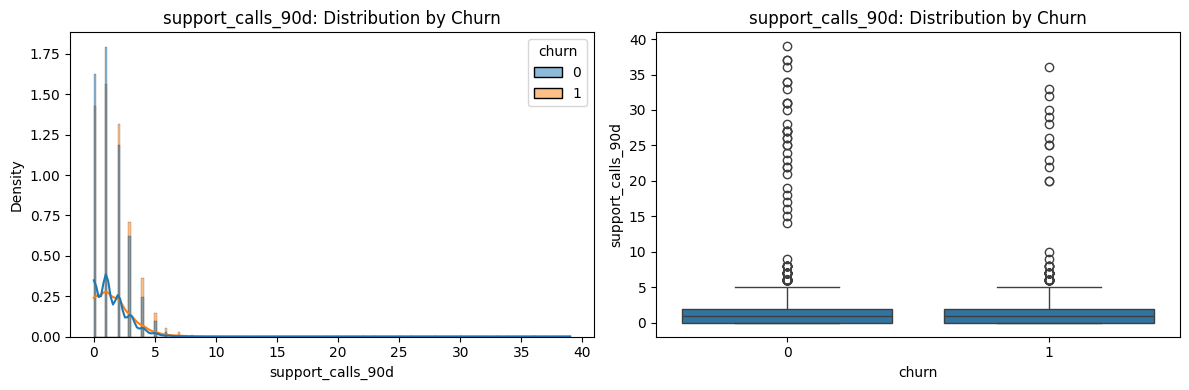

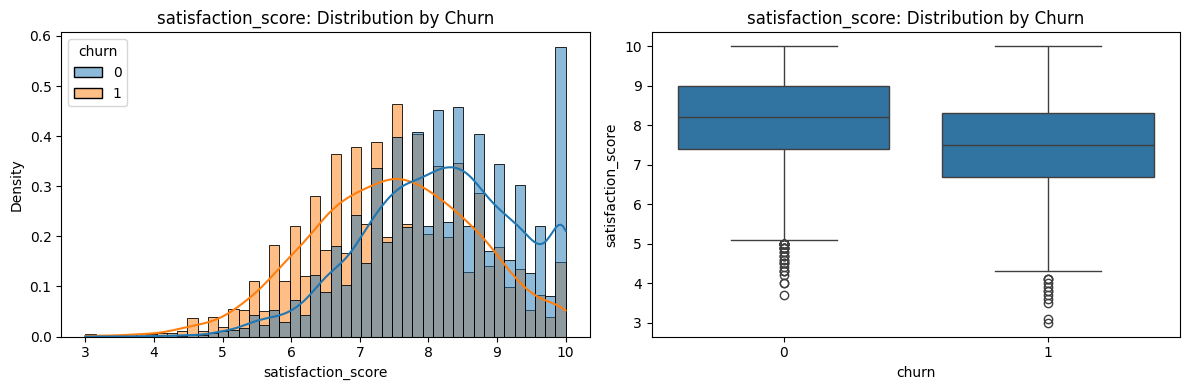

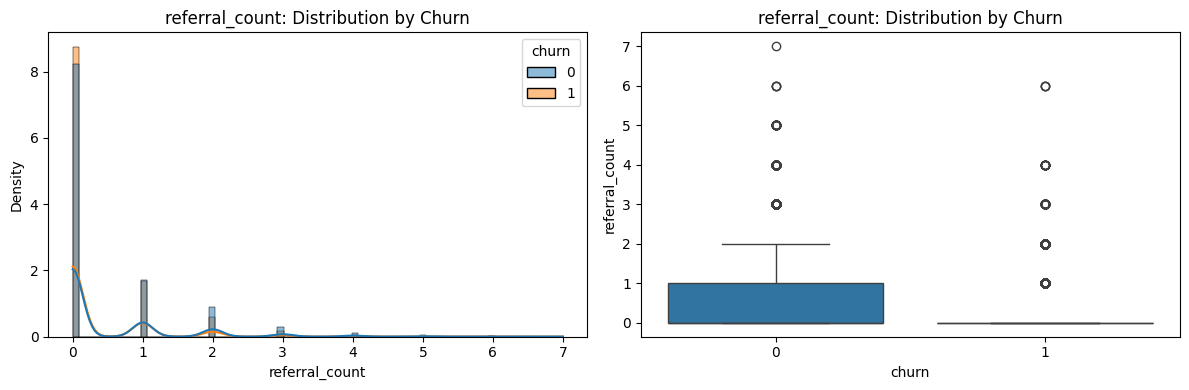

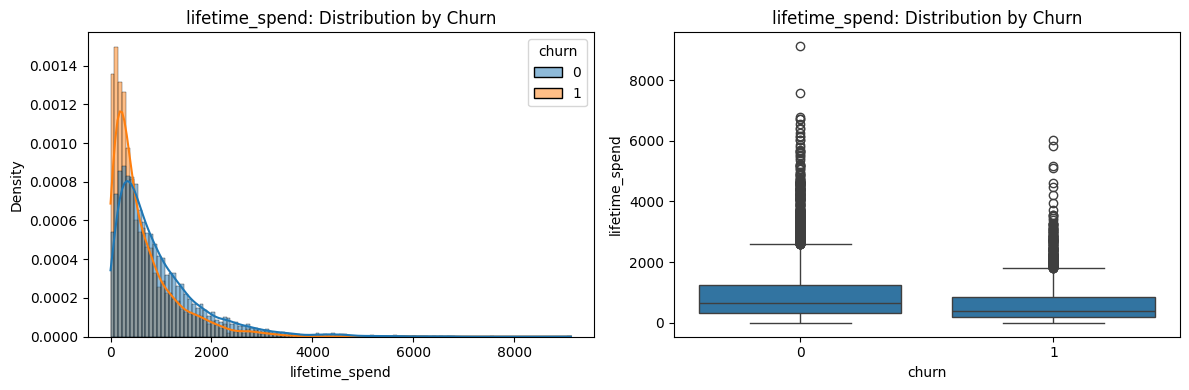

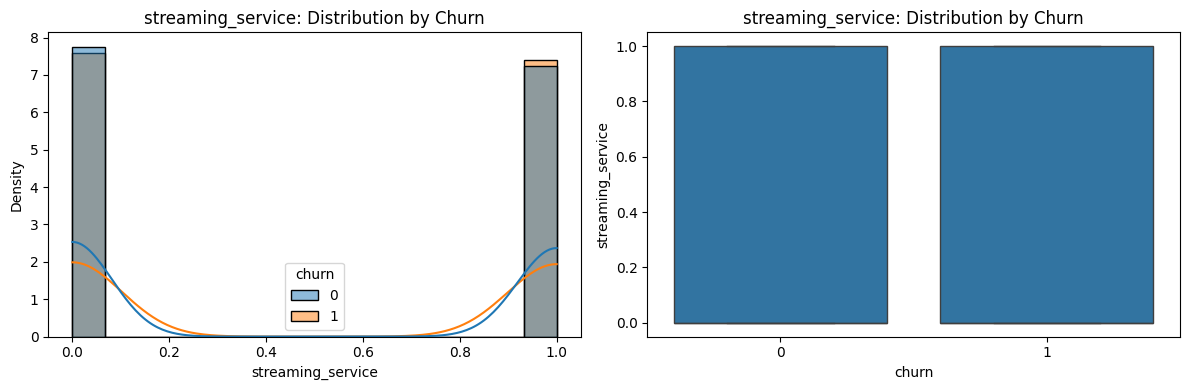

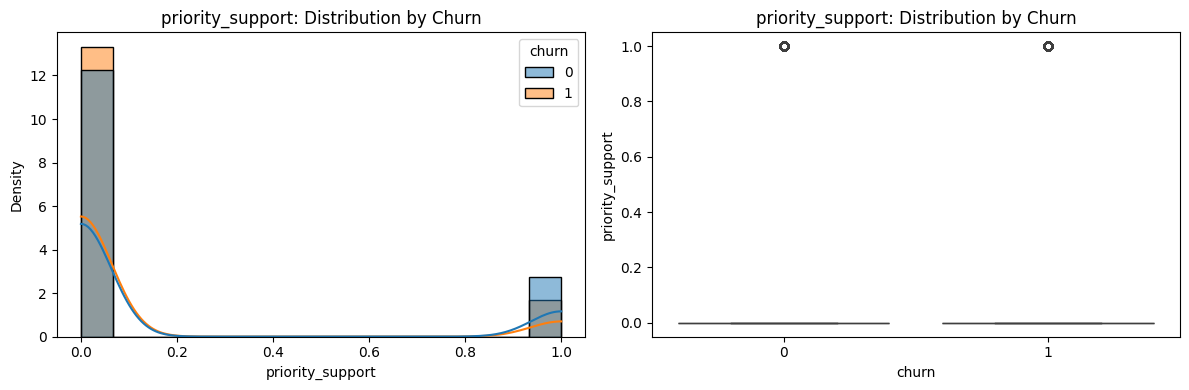

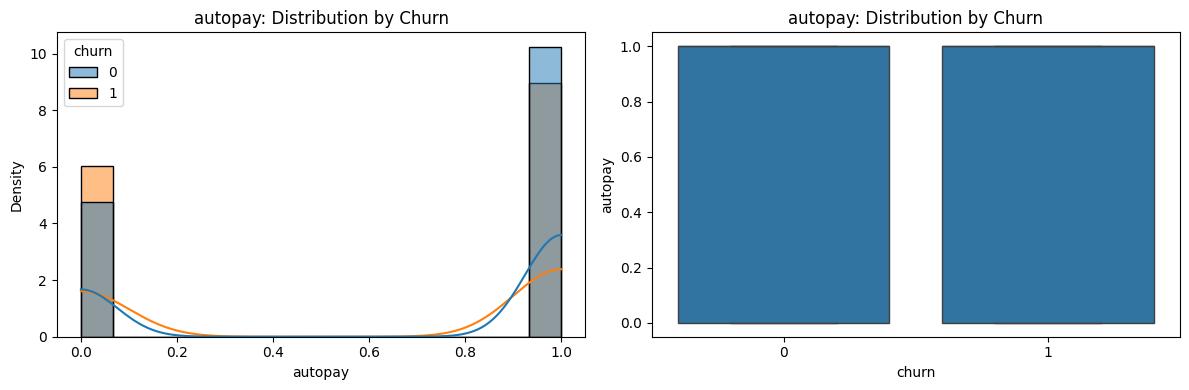

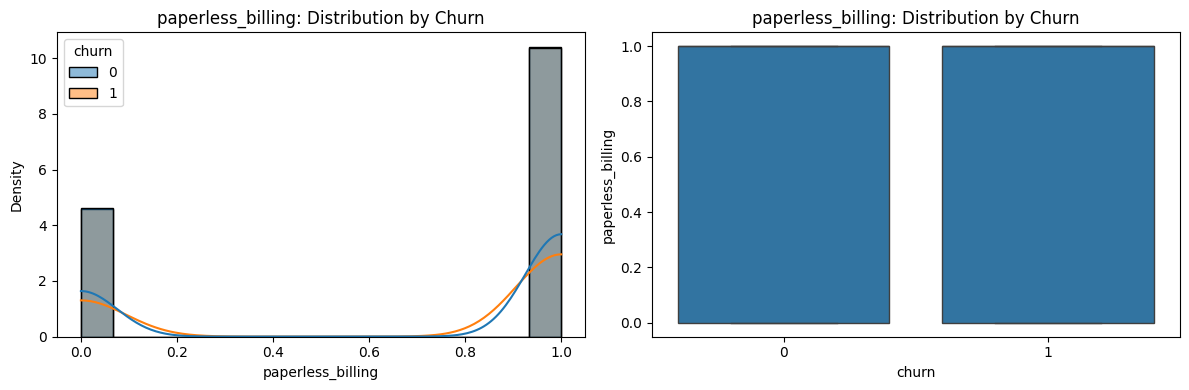

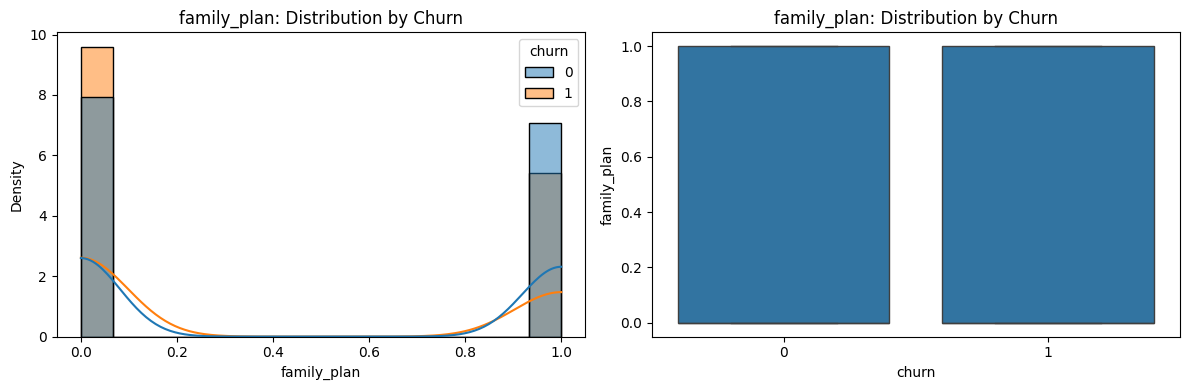

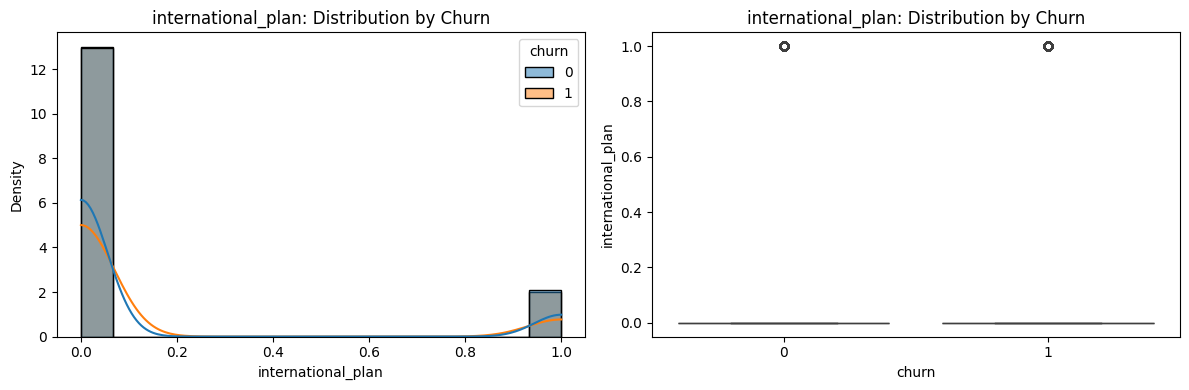

In [24]:
for col in numeric_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=train,
        x=col,
        hue="churn",
        kde=True,
        stat="density",
        common_norm=False,
        ax=axes[0]
    )

    axes[0].set_title(f"{col}: Distribution by Churn")

    sns.boxplot(
        data=train,
        x="churn",
        y=col,
        ax=axes[1]
    )

    axes[1].set_title(f"{col}: Distribution by Churn")

    plt.tight_layout()
    plt.show()

In [25]:
numeric_comparison = []

for col in numeric_cols:

    churned = train.loc[
        train["churn"] == 1, col
    ]

    retained = train.loc[
        train["churn"] == 0, col
    ]

    numeric_comparison.append({
        "Feature": col,
        "Churn_Median": churned.median(),
        "Retained_Median": retained.median(),
        "Median_Difference":
            churned.median() - retained.median()
    })

numeric_comparison_df = pd.DataFrame(
    numeric_comparison
)

numeric_comparison_df

,Feature,Churn_Median,Retained_Median,Median_Difference
0,age,39.000,43.00,-4.000
1,tenure_months,10.000,18.00,-8.000
2,number_of_services,2.000,2.00,0.000
3,data_usage_gb,12.335,11.69,0.645
4,streaming_hours_monthly,3.000,1.80,1.200
5,device_age_months,7.000,9.00,-2.000
6,app_sessions_weekly,12.000,12.00,0.000
7,average_session_minutes,9.000,9.20,-0.200
8,payment_delay_days,0.000,0.00,0.000
9,late_payment_count,0.000,0.00,0.000


## Non Linear Relationship checking

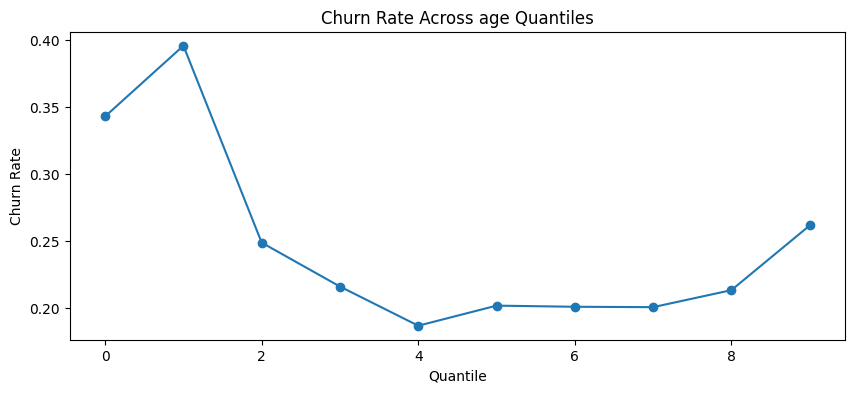

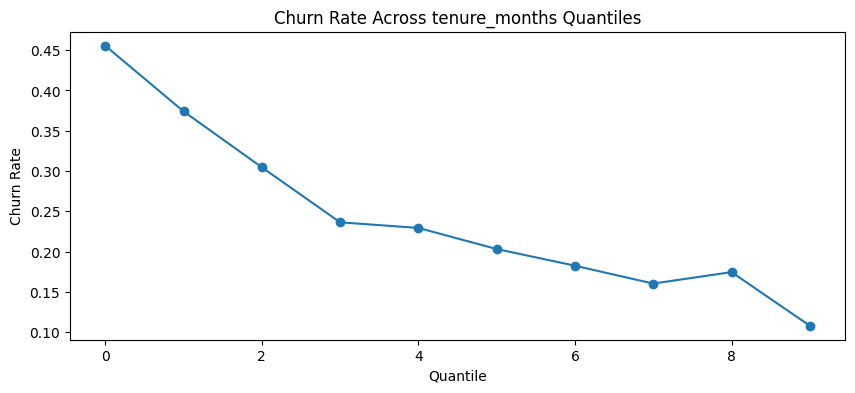

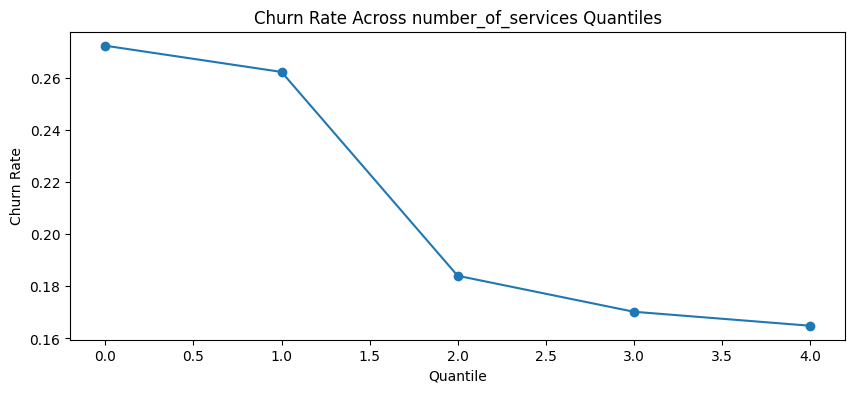

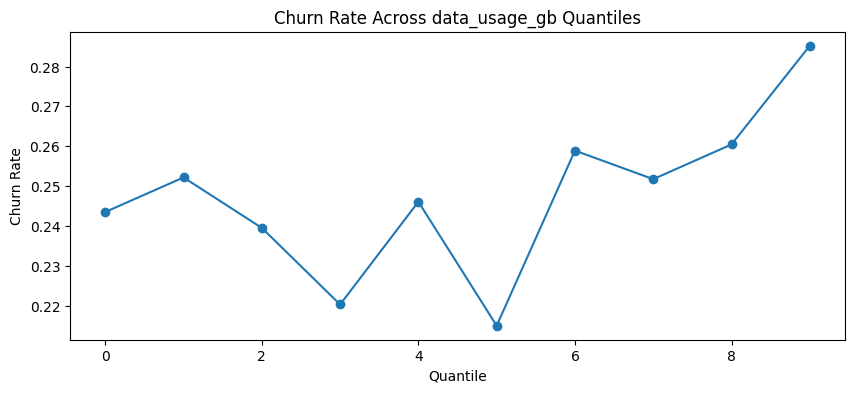

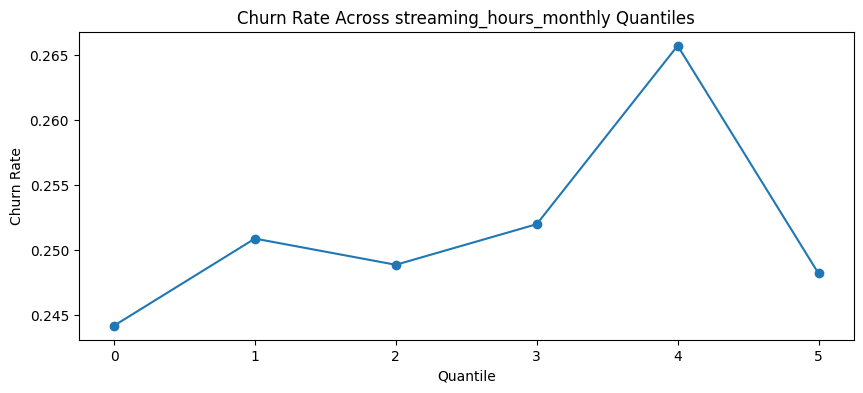

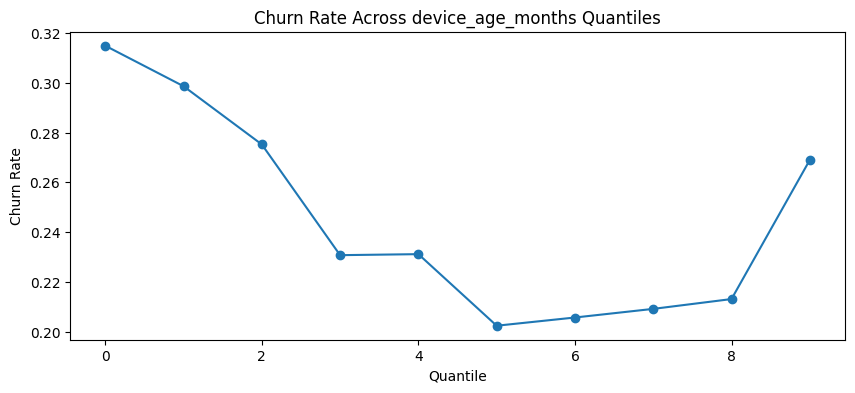

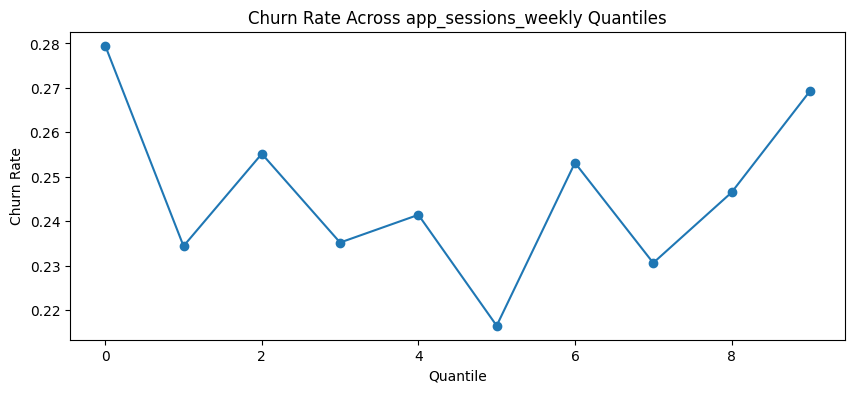

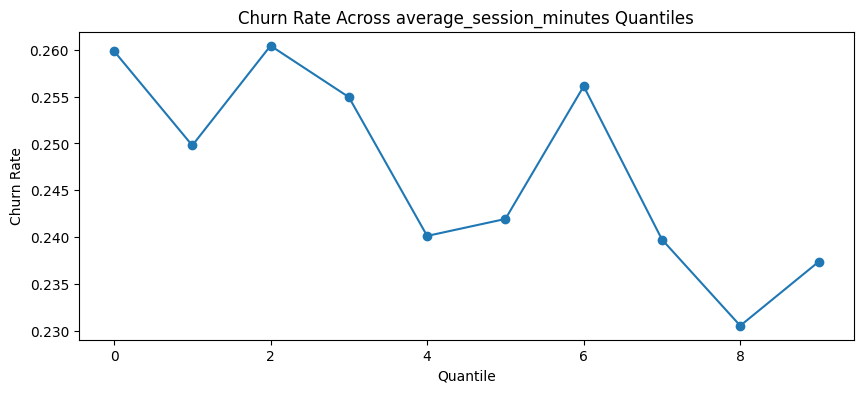

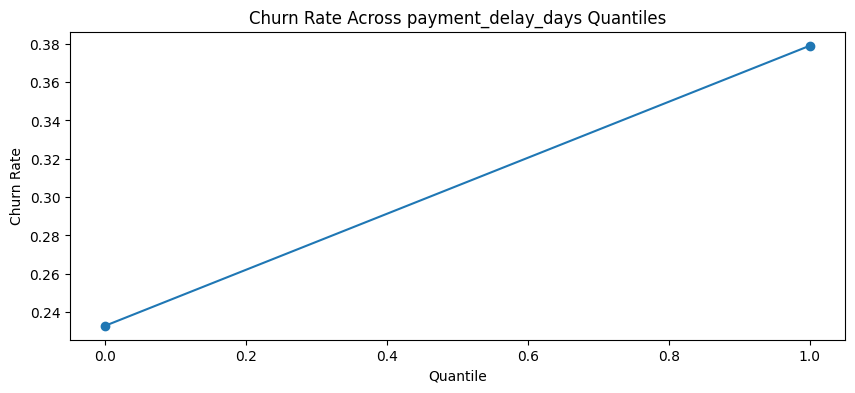

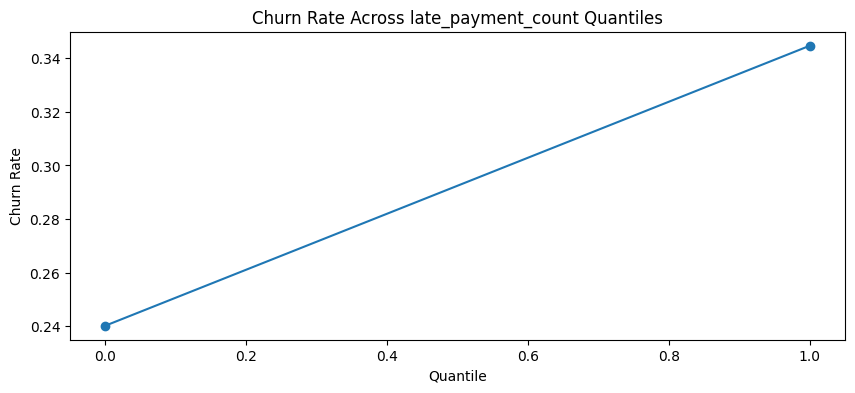

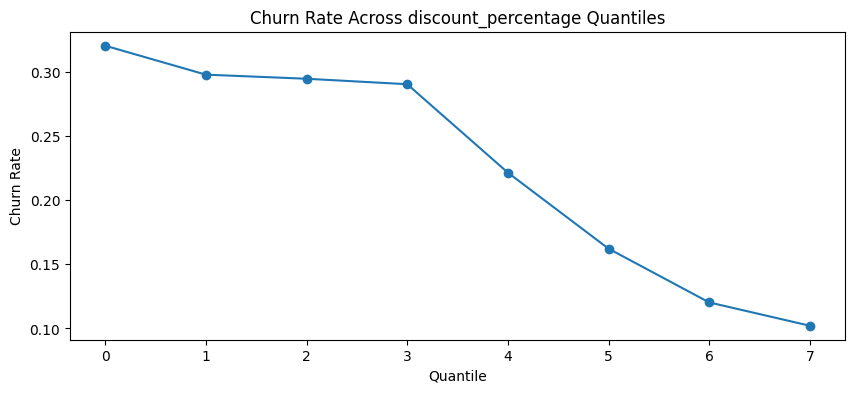

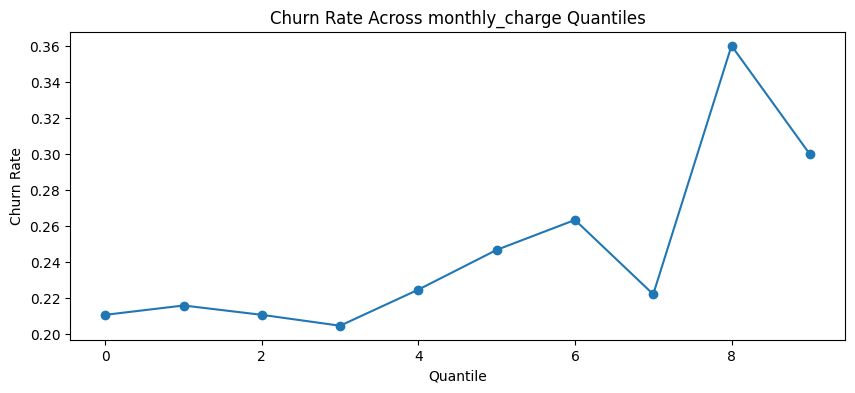

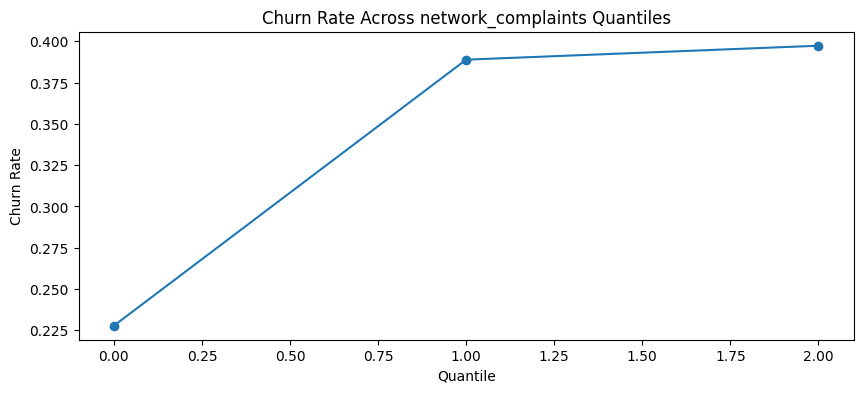

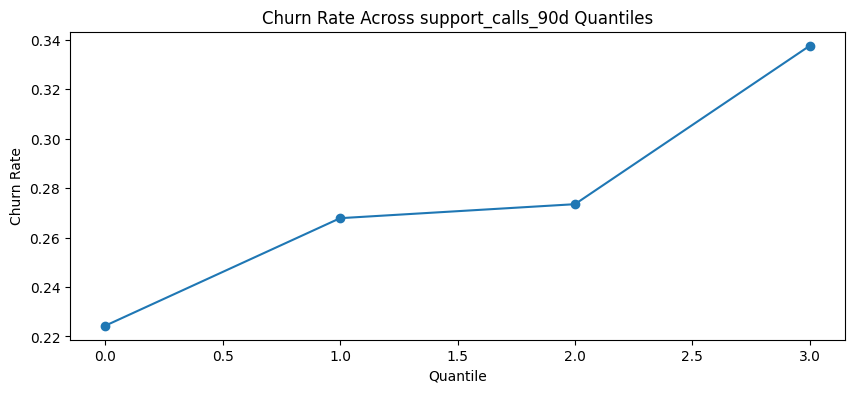

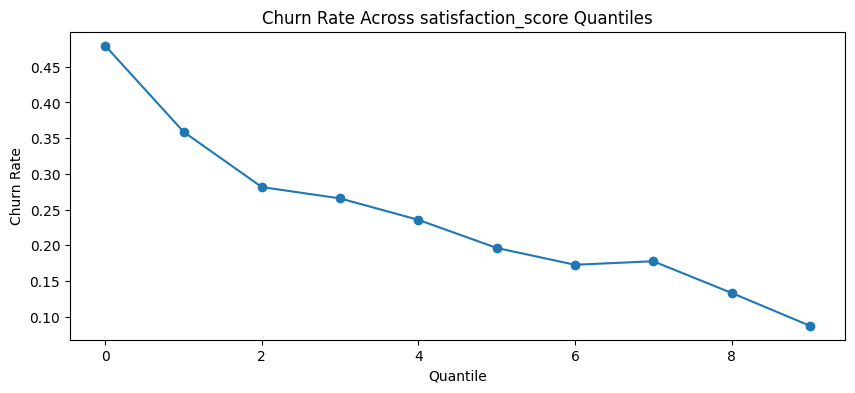

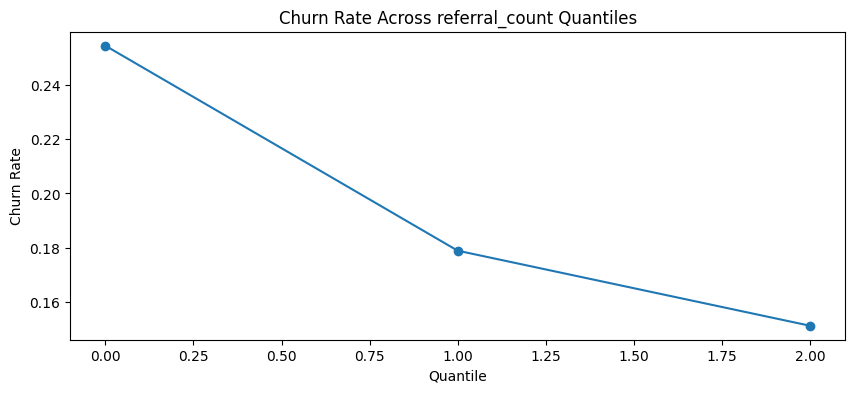

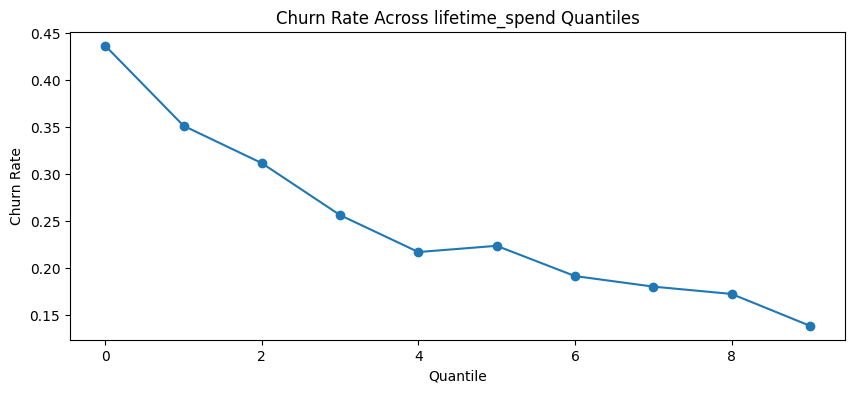

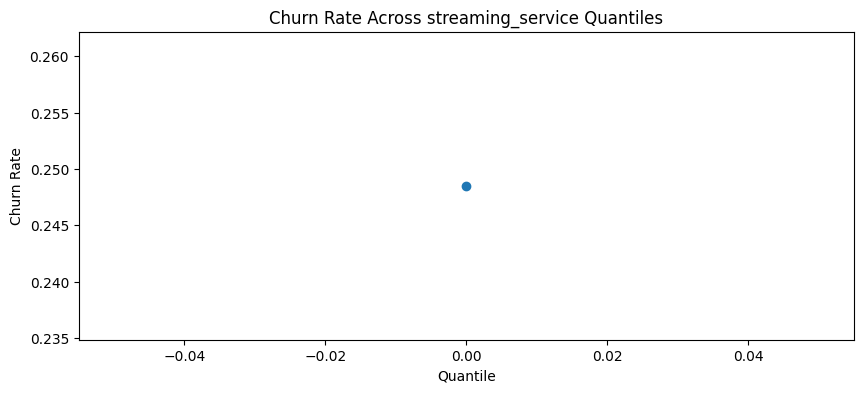

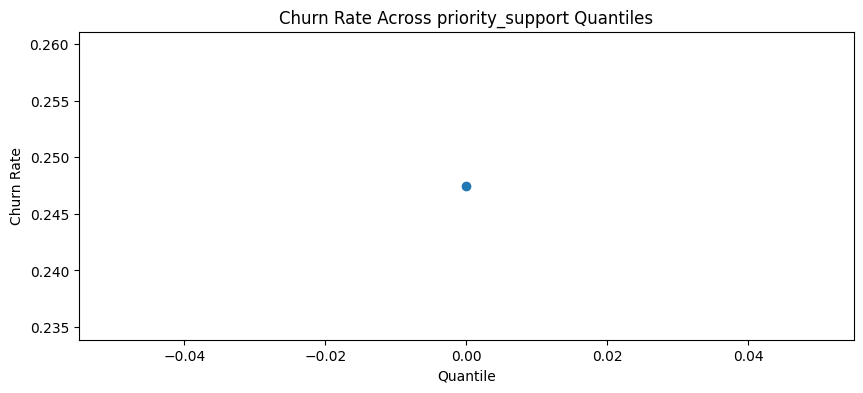

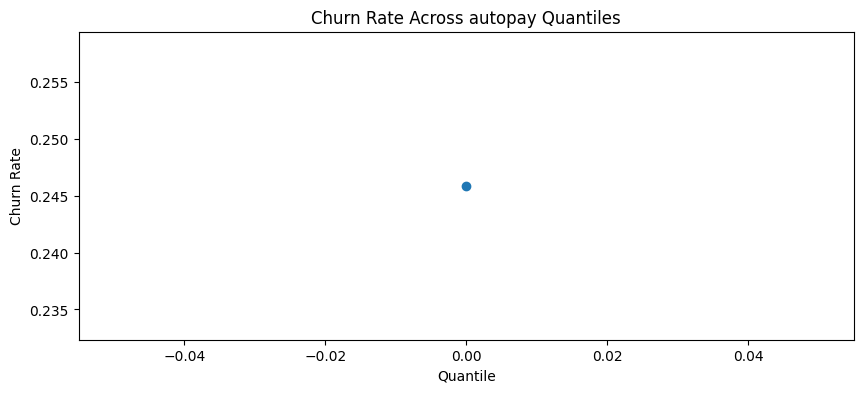

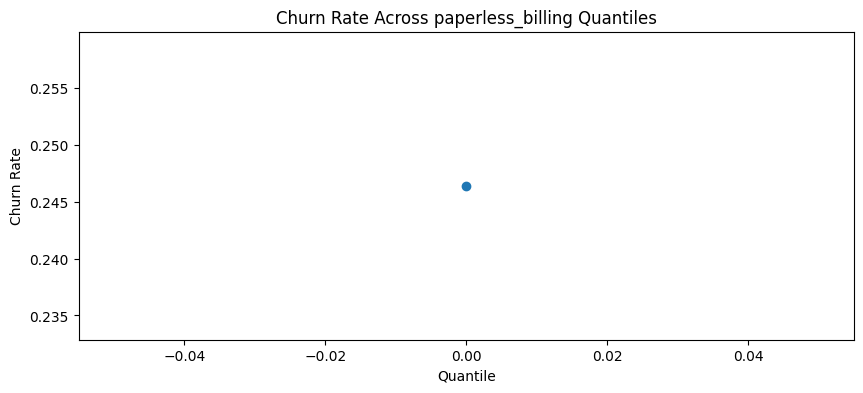

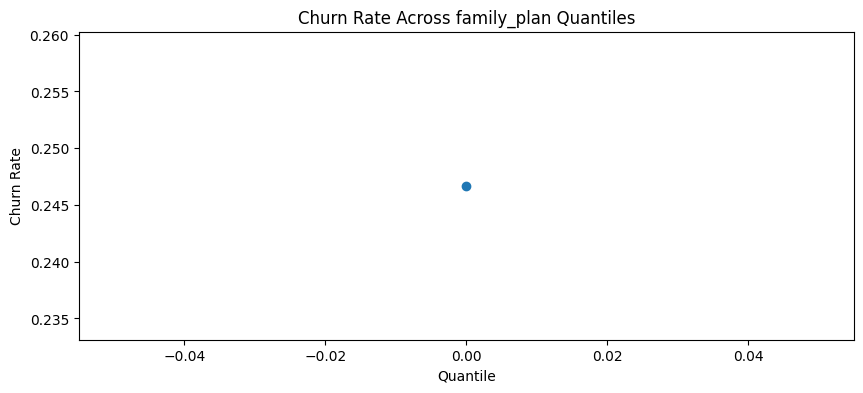

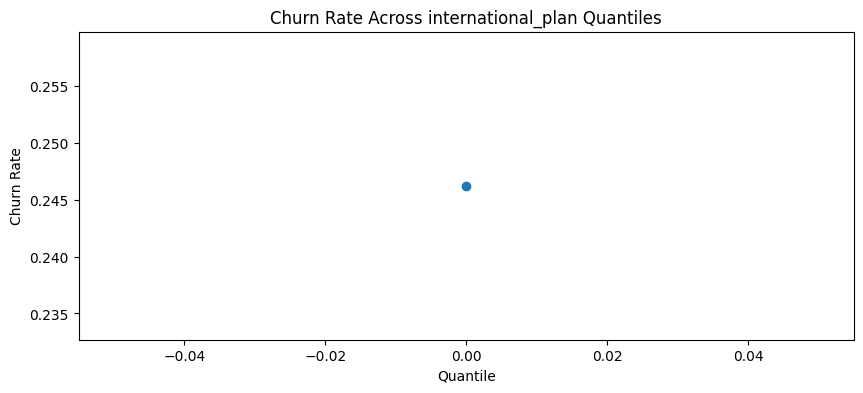

In [26]:
for col in numeric_cols:

    temp = train[[col, "churn"]].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[col],
        q=10,
        duplicates="drop"
    )

    churn_by_bin = (
        temp.groupby("bin", observed=True)["churn"]
        .mean()
    )

    plt.figure(figsize=(10, 4))

    plt.plot(
        range(len(churn_by_bin)),
        churn_by_bin.values,
        marker="o"
    )

    plt.title(
        f"Churn Rate Across {col} Quantiles"
    )

    plt.xlabel("Quantile")
    plt.ylabel("Churn Rate")

    plt.show()

# Feature interactions

I have planned many feature there is huge chance to improve here i have tested multiple times the combination of many features which will really create impact to go to a solution of the problem 

**Contract × tenure**

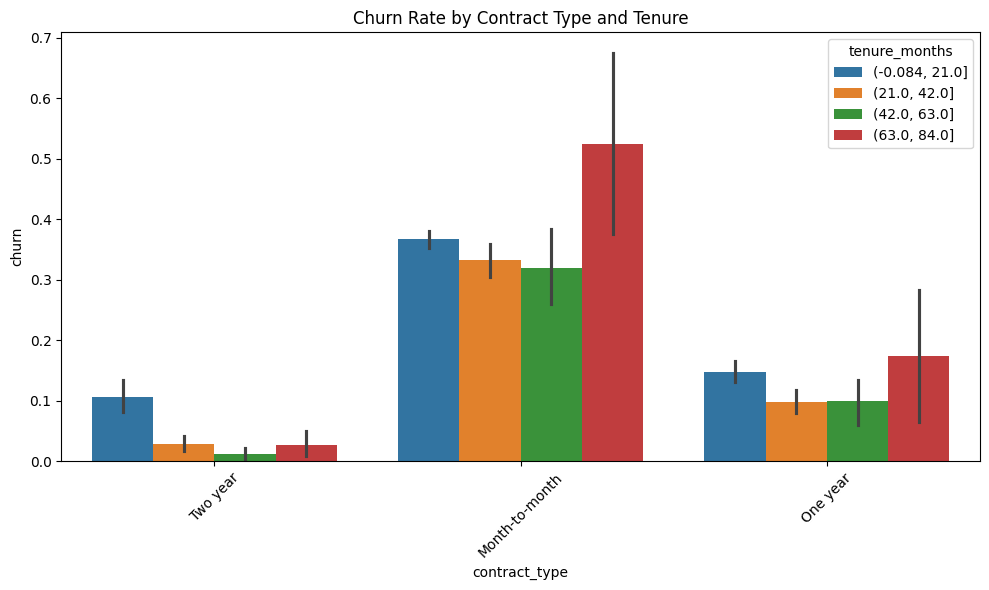

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=train,
    x="contract_type",
    y="churn",
    hue=pd.cut(
        train["tenure_months"],
        bins=4
    )
)

plt.title(
    "Churn Rate by Contract Type and Tenure"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Satisfaction × support calls**

/tmp/ipykernel_58/436599903.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  interaction = pd.pivot_table(


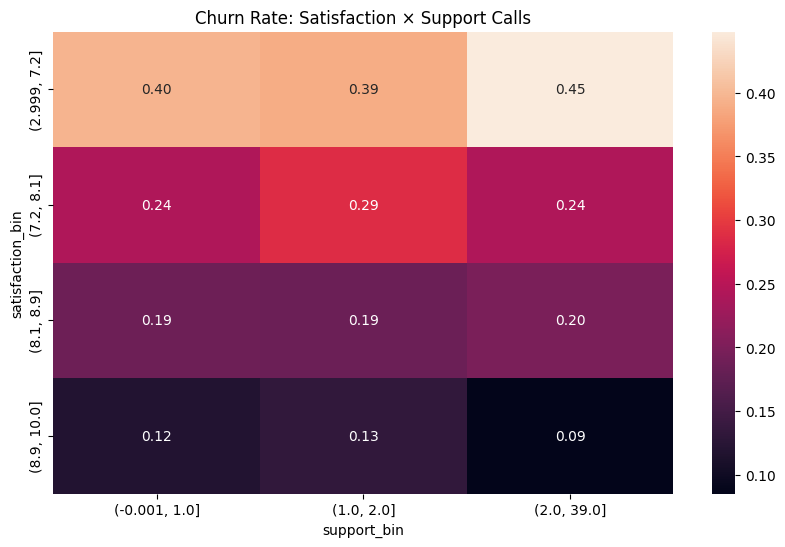

In [28]:
temp = train.copy()

temp["satisfaction_bin"] = pd.qcut(
    temp["satisfaction_score"],
    q=4,
    duplicates="drop"
)

temp["support_bin"] = pd.qcut(
    temp["support_calls_90d"],
    q=4,
    duplicates="drop"
)

interaction = pd.pivot_table(
    temp,
    values="churn",
    index="satisfaction_bin",
    columns="support_bin",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    interaction,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Churn Rate: Satisfaction × Support Calls"
)

plt.show()

**Segment-specific behavior**

In [29]:
segment_features = [
    "customer_segment",
    "region",
    "plan_tier",
    "contract_type"
]

for col in segment_features:

    summary = (
        train.groupby(col)["churn"]
        .agg(
            Customers="count",
            Churn_Rate="mean"
        )
        .sort_values(
            "Churn_Rate",
            ascending=False
        )
    )

    display(summary)

,Customers,Churn_Rate
customer_segment,,
Student,2658,0.379985
Consumer,6828,0.232279
Small Business,1305,0.153257
Enterprise,856,0.096963


,Customers,Churn_Rate
region,,
Centralia,1656,0.283213
Northgate,3200,0.264062
Westhaven,2140,0.235047
Eastvale,2795,0.234705
Southport,1905,0.220997


,Customers,Churn_Rate
plan_tier,,
NovaStart,4856,0.262356
NovaPlus,4734,0.249683
NovaMax,1920,0.206771


,Customers,Churn_Rate
contract_type,,
Month-to-month,6728,0.360285
One year,2986,0.126591
Two year,1993,0.044656


**Segment × contract**

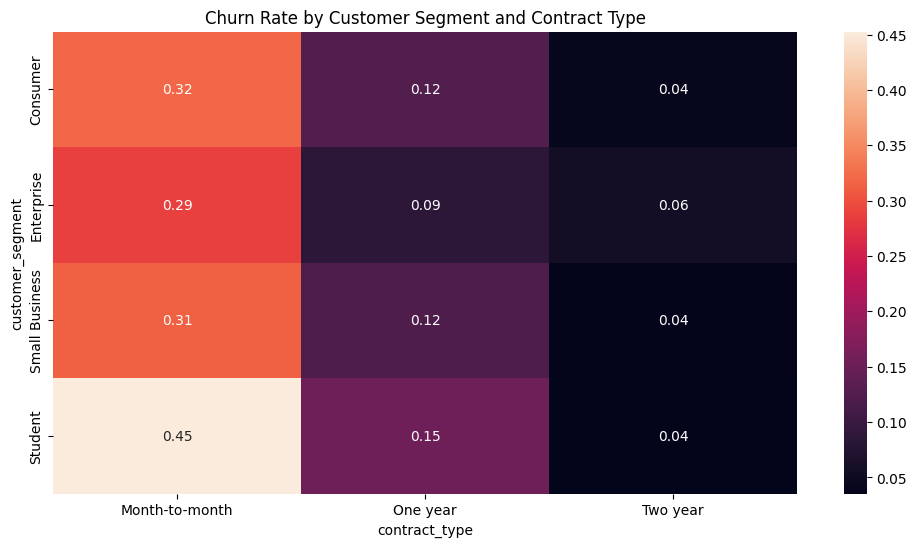

In [30]:
segment_contract = pd.pivot_table(
    train,
    values="churn",
    index="customer_segment",
    columns="contract_type",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    segment_contract,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Churn Rate by Customer Segment and Contract Type"
)

plt.show()

## Redundant Variables

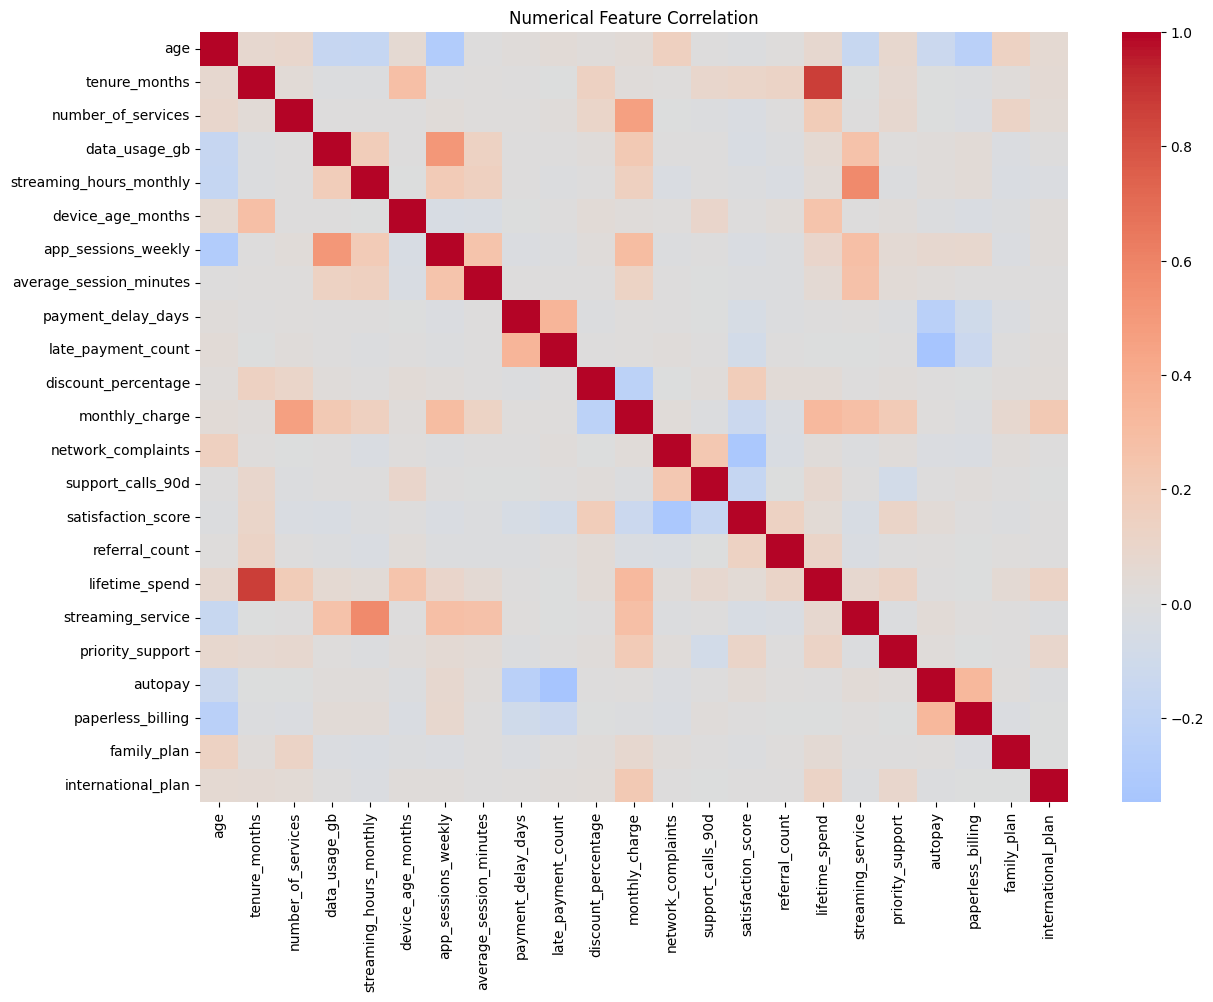

In [31]:
corr = train[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")

plt.show()

## Highly Correlated feature

In [33]:
import numpy as np
corr_pairs = (
    corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

corr_pairs = (
    corr_pairs
    .assign(
        Abs_Correlation=lambda x:
        x["Correlation"].abs()
    )
    .sort_values(
        "Abs_Correlation",
        ascending=False
    )
)

corr_pairs.head(20)

,Feature_1,Feature_2,Correlation,Abs_Correlation
36,tenure_months,lifetime_spend,0.872790,0.872790
94,streaming_hours_monthly,streaming_service,0.572603,0.572603
65,data_usage_gb,app_sessions_weekly,0.513421,0.513421
51,number_of_services,monthly_charge,0.461982,0.461982
148,payment_delay_days,late_payment_count,0.349416,0.349416
171,late_payment_count,autopay,-0.346686,0.346686
247,autopay,paperless_billing,0.328550,0.328550
199,network_complaints,satisfaction_score,-0.322926,0.322926
191,monthly_charge,lifetime_spend,0.321746,0.321746
121,app_sessions_weekly,monthly_charge,0.301496,0.301496


As i will use Tree-based models. They can often tolerate correlated predictors, while redundant variables can still be useful if they represent different business concepts.
Therefore, correlations are treated as an investigation tool rather than an automatic feature-removal rule for me but anyone can work with this 

# Hypothesis-Driven Feature Engineering

Rather than generating many arbitrary transformations, I create features based on interpretable customer-behavior hypotheses.

### Hypothesis 1 — Engagement intensity

A customer who uses the application frequently and spends more time per session may exhibit different retention behavior.

Therefore:

`total_engagement = app_sessions_weekly × average_session_minutes`

### Hypothesis 2 — Support pressure

Frequent support calls combined with network complaints may represent customer friction.

Therefore:

`support_pressure = support_calls_90d + network_complaints`

### Hypothesis 3 — Spending intensity

Lifetime spend alone is strongly related to tenure. Dividing lifetime spend by tenure provides an approximate monthly spending intensity.

Therefore:

`monthly_lifetime_spend = lifetime_spend / tenure_months`

More feature need to add and create 

# Pipeline

In [34]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import roc_auc_score

X = train.drop(columns=["churn", "customer_id"])
y = train["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12000, 33)
y shape: (12000,)


## Preprocessor 

In [37]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

## I will choose Stratify K fold Cross Validation cause it is an imbalance problem 

In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models

In [38]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

## Just simple LR not give too much effort 

In [39]:
logistic_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV scores:")
print(logistic_scores)

print("\nMean ROC-AUC:", logistic_scores.mean())
print("Std:", logistic_scores.std())

Logistic Regression CV scores:
[0.79364891 0.79340132 0.80725509 0.80937072 0.80288386]

Mean ROC-AUC: 0.801311979744343
Std: 0.006693813556732458


## Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [41]:
rf_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest CV scores:")
print(rf_scores)

print("\nMean ROC-AUC:", rf_scores.mean())
print("Std:", rf_scores.std())

Random Forest CV scores:
[0.80029075 0.79919577 0.80890037 0.80654397 0.80704045]

Mean ROC-AUC: 0.8043942614243104
Std: 0.003893372114761278


## CatBoost 

In [42]:
!pip install catboost -q

In [44]:
from catboost import CatBoostClassifier
X_cat = X.copy()

for col in categorical_cols:
    X_cat[col] = X_cat[col].fillna("Missing")
    
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

catboost_scores = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_cat, y), 1
):

    X_train = X_cat.iloc[train_idx]
    X_valid = X_cat.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_cols
    )

    pred = model.predict_proba(X_valid)[:, 1]

    score = roc_auc_score(y_valid, pred)

    catboost_scores.append(score)

    print(f"Fold {fold}: {score:.4f}")

print("\nCatBoost Mean ROC-AUC:",
      np.mean(catboost_scores))

print("CatBoost Std:",
      np.std(catboost_scores))

Fold 1: 0.8006
Fold 2: 0.8067
Fold 3: 0.8165
Fold 4: 0.8157
Fold 5: 0.8140

CatBoost Mean ROC-AUC: 0.8106940148328718
CatBoost Std: 0.00610827792121069


In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],
    "CV ROC-AUC": [
        logistic_scores.mean(),
        rf_scores.mean(),
        np.mean(catboost_scores)
    ],
    "CV Std": [
        logistic_scores.std(),
        rf_scores.std(),
        np.std(catboost_scores)
    ]
})

results.sort_values(
    "CV ROC-AUC",
    ascending=False
)

,Model,CV ROC-AUC,CV Std
2,CatBoost,0.810694,0.006108
1,Random Forest,0.804394,0.003893
0,Logistic Regression,0.801312,0.006694


In [48]:
final_catboost = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

final_catboost.fit(
    X_cat,
    y,
    cat_features=categorical_cols
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

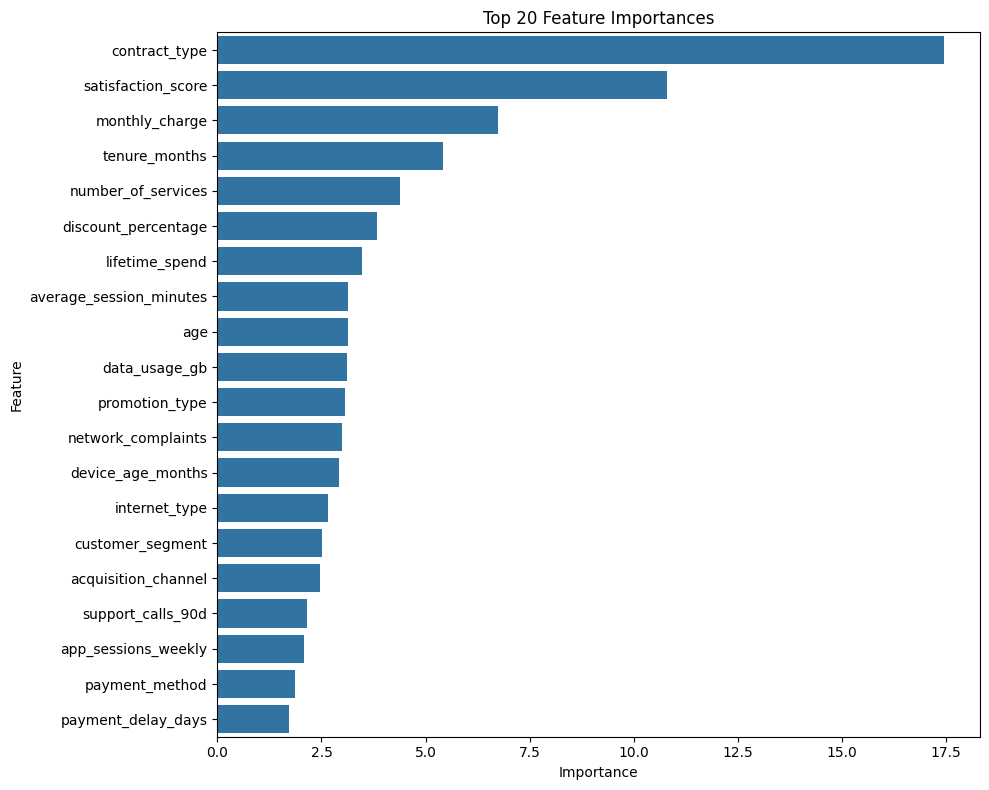

In [50]:
importance_df = pd.DataFrame({
    "Feature": X_cat.columns,
    "Importance": final_catboost.get_feature_importance()
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)


plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## Fine tune and Hyperparameter Tuning 

**I have tuned and did the hyperparameter tuning on different notebook for merging i just copying here cause this will take nearly 40 minutes+ for the result i got the result before so i dont want to run it again but i provided the code so anyone can run it**

## Catboost Fine Tuning

In [ ]:

# import itertools
# catboost_params = {
#     "iterations": [300, 500, 800],
#     "depth": [4, 6, 8],
#     "learning_rate": [0.03, 0.05, 0.1]
# }
# catboost_results = []

# for iterations, depth, learning_rate in itertools.product(
#     catboost_params["iterations"],
#     catboost_params["depth"],
#     catboost_params["learning_rate"]
# ):

#     fold_scores = []

#     for fold, (train_idx, valid_idx) in enumerate(
#         cv.split(X_fe, y), 1
#     ):

#         X_train = X_fe.iloc[train_idx]
#         X_valid = X_fe.iloc[valid_idx]

#         y_train = y.iloc[train_idx]
#         y_valid = y.iloc[valid_idx]

#         model = CatBoostClassifier(
#             iterations=iterations,
#             depth=depth,
#             learning_rate=learning_rate,

#             loss_function="Logloss",
#             eval_metric="AUC",

#             verbose=False,
#             random_seed=42,
#             allow_writing_files=False
#         )

#         model.fit(
#             X_train,
#             y_train,
#             cat_features=categorical_cols
#         )

#         pred = model.predict_proba(X_valid)[:, 1]

#         score = roc_auc_score(
#             y_valid,
#             pred
#         )

#         fold_scores.append(score)

#     mean_score = np.mean(fold_scores)
#     std_score = np.std(fold_scores)

#     catboost_results.append({
#         "iterations": iterations,
#         "depth": depth,
#         "learning_rate": learning_rate,
#         "mean_auc": mean_score,
#         "std_auc": std_score
#     })

#     print(
#         f"iterations={iterations}, "
#         f"depth={depth}, "
#         f"lr={learning_rate} "
#         f"→ AUC={mean_score:.5f}"
#     )
# catboost_results_df = pd.DataFrame(catboost_results)

# catboost_results_df = catboost_results_df.sort_values(
#     "mean_auc",
#     ascending=False
# )

# catboost_results_df.head(10)




# For understanding easily i am providing the result i got from that notebook 

# iterations=300, depth=4, lr=0.03 → AUC=0.80925
# iterations=300, depth=4, lr=0.05 → AUC=0.81142
# iterations=300, depth=4, lr=0.1 → AUC=0.81051
# iterations=300, depth=6, lr=0.03 → AUC=0.81080
# iterations=300, depth=6, lr=0.05 → AUC=0.81180
# iterations=300, depth=6, lr=0.1 → AUC=0.80848
# iterations=300, depth=8, lr=0.03 → AUC=0.81029
# iterations=300, depth=8, lr=0.05 → AUC=0.80780
# iterations=300, depth=8, lr=0.1 → AUC=0.80067
# iterations=500, depth=4, lr=0.03 → AUC=0.81148
# iterations=500, depth=4, lr=0.05 → AUC=0.81189
# iterations=500, depth=4, lr=0.1 → AUC=0.80942
# iterations=500, depth=6, lr=0.03 → AUC=0.81241
# iterations=500, depth=6, lr=0.05 → AUC=0.81126
# iterations=500, depth=6, lr=0.1 → AUC=0.80400
# iterations=500, depth=8, lr=0.03 → AUC=0.81118
# iterations=500, depth=8, lr=0.05 → AUC=0.80604
# iterations=500, depth=8, lr=0.1 → AUC=0.79775
# iterations=800, depth=4, lr=0.03 → AUC=0.81239
# iterations=800, depth=4, lr=0.05 → AUC=0.81109
# iterations=800, depth=4, lr=0.1 → AUC=0.80475
# iterations=800, depth=6, lr=0.03 → AUC=0.81225
# iterations=800, depth=6, lr=0.05 → AUC=0.80881
# iterations=800, depth=6, lr=0.1 → AUC=0.79911
# iterations=800, depth=8, lr=0.03 → AUC=0.80985
# iterations=800, depth=8, lr=0.05 → AUC=0.80291
# iterations=800, depth=8, lr=0.1 → AUC=0.79548

## XGBoost Fine Tuning 

In [60]:
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# xgb_params = {
#     "n_estimators": [300, 500],
#     "max_depth": [3, 5, 7],
#     "learning_rate": [0.03, 0.05, 0.1]
# }
# xgb_results = []

# for n_estimators, max_depth, learning_rate in itertools.product(
#     xgb_params["n_estimators"],
#     xgb_params["max_depth"],
#     xgb_params["learning_rate"]
# ):

#     fold_scores = []

#     for fold, (train_idx, valid_idx) in enumerate(
#         cv.split(X_xgb, y), 1
#     ):

#         X_train = X_xgb.iloc[train_idx]
#         X_valid = X_xgb.iloc[valid_idx]

#         y_train = y.iloc[train_idx]
#         y_valid = y.iloc[valid_idx]

#         model = XGBClassifier(
#             n_estimators=n_estimators,
#             max_depth=max_depth,
#             learning_rate=learning_rate,

#             objective="binary:logistic",
#             eval_metric="auc",

#             subsample=0.8,
#             colsample_bytree=0.8,

#             random_state=42,
#             n_jobs=-1
#         )

#         model.fit(
#             X_train,
#             y_train
#         )

#         pred = model.predict_proba(X_valid)[:, 1]

#         score = roc_auc_score(
#             y_valid,
#             pred
#         )

#         fold_scores.append(score)

#     mean_score = np.mean(fold_scores)
#     std_score = np.std(fold_scores)

#     xgb_results.append({
#         "n_estimators": n_estimators,
#         "max_depth": max_depth,
#         "learning_rate": learning_rate,
#         "mean_auc": mean_score,
#         "std_auc": std_score
#     })

#     print(
#         f"n_estimators={n_estimators}, "
#         f"depth={max_depth}, "
#         f"lr={learning_rate} "
#         f"→ AUC={mean_score:.5f}"
#     )


# Result i got 
# n_estimators=300, depth=3, lr=0.03 → AUC=0.81330
# n_estimators=300, depth=3, lr=0.05 → AUC=0.81396
# n_estimators=300, depth=3, lr=0.1 → AUC=0.80996
# n_estimators=300, depth=5, lr=0.03 → AUC=0.81307
# n_estimators=300, depth=5, lr=0.05 → AUC=0.80940
# n_estimators=300, depth=5, lr=0.1 → AUC=0.80216
# n_estimators=300, depth=7, lr=0.03 → AUC=0.80818
# n_estimators=300, depth=7, lr=0.05 → AUC=0.80341
# n_estimators=300, depth=7, lr=0.1 → AUC=0.79363
# n_estimators=500, depth=3, lr=0.03 → AUC=0.81377
# n_estimators=500, depth=3, lr=0.05 → AUC=0.81224
# n_estimators=500, depth=3, lr=0.1 → AUC=0.80608
# n_estimators=500, depth=5, lr=0.03 → AUC=0.81082
# n_estimators=500, depth=5, lr=0.05 → AUC=0.80500
# n_estimators=500, depth=5, lr=0.1 → AUC=0.79488
# n_estimators=500, depth=7, lr=0.03 → AUC=0.80517
# n_estimators=500, depth=7, lr=0.05 → AUC=0.79938
# n_estimators=500, depth=7, lr=0.1 → AUC=0.79319

## Blending XGBoost and CatBoost

In [51]:
best_xgb_params = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05
}

best_catboost_params = {
    "iterations": 500,
    "depth": 6,
    "learning_rate": 0.03
}

In [53]:
X_fe = X.copy()

X_fe["total_engagement"] = (
    X_fe["app_sessions_weekly"] *
    X_fe["average_session_minutes"]
)

# Support pressure 
X_fe["support_pressure"] = (
    X_fe["support_calls_90d"] +
    X_fe["network_complaints"]
)

# Payment problem from customer side (cancelled) testing done giving bad result 
# X_fe["payment_risk"] = (
#     X_fe["payment_delay_days"] *
#     (1 + X_fe["late_payment_count"])
# )

# Spending per tenure month
X_fe["monthly_lifetime_spend"] = (
    X_fe["lifetime_spend"] /
    X_fe["tenure_months"].clip(lower=1)
)


In [54]:
oof_cat = np.zeros(len(X_fe))
oof_xgb = np.zeros(len(X_fe))

best_cat_iterations = int(
    best_catboost_params["iterations"]
)

best_cat_depth = int(
    best_catboost_params["depth"]
)

best_cat_lr = float(
    best_catboost_params["learning_rate"]
)

best_xgb_estimators = int(
    best_xgb_params["n_estimators"]
)

best_xgb_depth = int(
    best_xgb_params["max_depth"]
)

best_xgb_lr = float(
    best_xgb_params["learning_rate"]
)

In [57]:
categorical_cols_fe = X_fe.select_dtypes(
    include=["object"]
).columns.tolist()
print(categorical_cols_fe)

X_fe[categorical_cols_fe] = X_fe[categorical_cols_fe].fillna("Missing")

X_xgb = X_fe.copy()
categorical_cols_xgb = (
    X_xgb
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

X_xgb = pd.get_dummies(
    X_xgb,
    columns=categorical_cols_xgb,
    dummy_na=False
)

['customer_segment', 'region', 'acquisition_channel', 'contract_type', 'plan_tier', 'internet_type', 'device_type', 'support_plan', 'payment_method', 'promotion_type']


In [61]:
for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_fe, y), 1
):

    print(f"\nFold {fold}")

    # =====================================
    # CatBoost
    # =====================================

    X_train_cat = X_fe.iloc[train_idx]
    X_valid_cat = X_fe.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    cat_model = CatBoostClassifier(
        iterations=best_cat_iterations,
        depth=best_cat_depth,
        learning_rate=best_cat_lr,

        loss_function="Logloss",
        eval_metric="AUC",

        verbose=False,
        random_seed=42,
        allow_writing_files=False
    )

    cat_model.fit(
        X_train_cat,
        y_train,
        cat_features=categorical_cols
    )

    oof_cat[valid_idx] = (
        cat_model.predict_proba(X_valid_cat)[:, 1]
    )


    # =====================================
    # XGBoost
    # =====================================

    X_train_xgb = X_xgb.iloc[train_idx]
    X_valid_xgb = X_xgb.iloc[valid_idx]

    xgb_model = XGBClassifier(
        n_estimators=best_xgb_estimators,
        max_depth=best_xgb_depth,
        learning_rate=best_xgb_lr,

        objective="binary:logistic",
        eval_metric="auc",

        subsample=0.8,
        colsample_bytree=0.8,

        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(
        X_train_xgb,
        y_train
    )

    oof_xgb[valid_idx] = (
        xgb_model.predict_proba(X_valid_xgb)[:, 1]
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [62]:
cat_oof_auc = roc_auc_score(
    y,
    oof_cat
)

xgb_oof_auc = roc_auc_score(
    y,
    oof_xgb
)

print("CatBoost OOF ROC-AUC:", cat_oof_auc)
print("XGBoost OOF ROC-AUC:", xgb_oof_auc)

CatBoost OOF ROC-AUC: 0.8124647197027887
XGBoost OOF ROC-AUC: 0.8132266340750635


## 50-50 blend

In [63]:
blend_50 = (
    0.5 * oof_cat +
    0.5 * oof_xgb
)

blend_auc = roc_auc_score(
    y,
    blend_50
)

print(
    "50/50 Blend ROC-AUC:",
    blend_auc
)

50/50 Blend ROC-AUC: 0.8145059398996086


In [64]:
#best blend
blend_results = []

for cat_weight in np.arange(0, 1.01, 0.05):

    xgb_weight = 1 - cat_weight

    blend_pred = (
        cat_weight * oof_cat +
        xgb_weight * oof_xgb
    )

    auc = roc_auc_score(
        y,
        blend_pred
    )

    blend_results.append({
        "cat_weight": cat_weight,
        "xgb_weight": xgb_weight,
        "auc": auc
    })

blend_results_df = pd.DataFrame(blend_results)

blend_results_df = blend_results_df.sort_values(
    "auc",
    ascending=False
)

blend_results_df.head(10)

,cat_weight,xgb_weight,auc
9,0.45,0.55,0.814523
8,0.40,0.60,0.814514
10,0.50,0.50,0.814506
7,0.35,0.65,0.814478
11,0.55,0.45,0.814450
6,0.30,0.70,0.814395
12,0.60,0.40,0.814376
5,0.25,0.75,0.814278
13,0.65,0.35,0.814251
4,0.20,0.80,0.814132


## Best Blend weight

In [65]:
best_blend = (
    0.40 * oof_cat +
    0.60 * oof_xgb
)

blend_auc = roc_auc_score(
    y,
    best_blend
)

print(
    "40/60 Blend ROC-AUC:",
    blend_auc
)

40/60 Blend ROC-AUC: 0.8145143054030957


In [66]:
X_final_cat = X_fe.copy()

In [67]:
categorical_cols_final = (
    X_final_cat
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

X_final_cat[categorical_cols_final] = (
    X_final_cat[categorical_cols_final]
    .fillna("Missing")
)

# Testing 

In [68]:
test = pd.read_csv("/kaggle/input/datasets/problemthinkerbox/novatel/test.csv")
X_test_cat = test.drop(
    columns=["customer_id"]
).copy()


X_test_cat["total_engagement"] = (
    X_test_cat["app_sessions_weekly"] *
    X_test_cat["average_session_minutes"]
)


X_test_cat["support_pressure"] = (
    X_test_cat["support_calls_90d"] +
    X_test_cat["network_complaints"]
)


X_test_cat["monthly_lifetime_spend"] = (
    X_test_cat["lifetime_spend"] /
    X_test_cat["tenure_months"].clip(lower=1)
)

In [69]:
X_test_cat[categorical_cols_final] = (
    X_test_cat[categorical_cols_final]
    .fillna("Missing")
)

In [70]:
print(
    "Train shape:",
    X_final_cat.shape
)

print(
    "Test shape:",
    X_test_cat.shape
)

Train shape: (12000, 36)
Test shape: (8000, 36)


In [71]:
iterations = 500
depth = 6
learning_rate = 0.03
final_cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42,
    allow_writing_files=False
)

final_cat.fit(
    X_final_cat,
    y,
    cat_features=categorical_cols_final
)

CatBoostClassifier(allow_writing_files=False, depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [72]:
test_pred_cat = final_cat.predict_proba(
    X_test_cat
)[:, 1]

In [73]:
X_xgb = X_fe.copy()

categorical_cols_xgb = (
    X_xgb
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

X_xgb = pd.get_dummies(
    X_xgb,
    columns=categorical_cols_xgb,
    dummy_na=False
)

X_xgb = X_xgb.astype(float)

In [74]:
X_test_xgb = X_test_cat.copy()
X_test_xgb = pd.get_dummies(
    X_test_xgb,
    columns=categorical_cols_xgb,
    dummy_na=False
)
X_test_xgb = X_test_xgb.reindex(
    columns=X_xgb.columns,
    fill_value=0
)
X_test_xgb = X_test_xgb.astype(float)

In [75]:
final_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,

    objective="binary:logistic",
    eval_metric="auc",

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)
final_xgb.fit(
    X_xgb,
    y
)
test_pred_xgb = final_xgb.predict_proba(
    X_test_xgb
)[:, 1]
print(test_pred_xgb[:10])

[0.2320508  0.10858721 0.38094306 0.38280016 0.07368466 0.3367291
 0.26669195 0.43378428 0.52380776 0.41007462]


In [76]:
test_pred = (
    0.40 * test_pred_cat +
    0.60 * test_pred_xgb
)

In [77]:
print("First 10 predictions:")
print(test_pred[:10])

print(
    "Min probability:",
    test_pred.min()
)

print(
    "Max probability:",
    test_pred.max()
)

print(
    "Mean probability:",
    test_pred.mean()
)

print(
    "Missing predictions:",
    np.isnan(test_pred).sum()
)

First 10 predictions:
[0.23261292 0.11492403 0.38263975 0.38349444 0.06826635 0.32447873
 0.2575398  0.42806536 0.54676403 0.38259251]
Min probability: 0.0015683351032063316
Max probability: 0.9719541757712483
Mean probability: 0.24862891364028933
Missing predictions: 0


In [78]:
submission = pd.DataFrame({
    "customer_id": test["customer_id"],
    "churn": test_pred
})
submission.to_csv(
    "submission34.csv",
    index=False
)